In [ ]:
# ==========================================
# Career Path Prediction System
# Step 1: Import Required Libraries
# ==========================================

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score

# Display all columns
pd.set_option('display.max_columns', None)

print("Libraries imported successfully.")

Libraries imported successfully.


In [ ]:
# ==========================================
# Step 2: Upload Dataset
# ==========================================

from google.colab import files

uploaded = files.upload()

Saving New Dataset.csv to New Dataset (1).csv


In [ ]:
# ==========================================
# Step 3: Load Dataset
# ==========================================

import pandas as pd

df = pd.read_csv("New Dataset.csv")

print("Dataset loaded successfully!")

Dataset loaded successfully!


In [ ]:
# ==========================================
# Step 5: Dataset Shape
# ==========================================

print("Number of Rows   :", df.shape[0])
print("Number of Columns:", df.shape[1])

Number of Rows   : 2000
Number of Columns: 25


In [ ]:
#data info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 25 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   age                2000 non-null   int64  
 1   gender             2000 non-null   object 
 2   degree_level       2000 non-null   object 
 3   field_of_study     2000 non-null   object 
 4   gpa                2000 non-null   float64
 5   years_experience   2000 non-null   int64  
 6   python             2000 non-null   int64  
 7   java               2000 non-null   int64  
 8   c_cpp              2000 non-null   int64  
 9   sql                2000 non-null   int64  
 10  machine_learning   2000 non-null   int64  
 11  data_analysis      2000 non-null   int64  
 12  cloud_computing    2000 non-null   int64  
 13  cybersecurity      2000 non-null   int64  
 14  web_development    2000 non-null   int64  
 15  devops             2000 non-null   int64  
 16  networking         2000 

In [ ]:
# ==========================================
# Step 7: Statistical Summary
# ==========================================

df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
age,2000.0,NaN,NaN,NaN,27.9915,4.347284,21.0,24.0,28.0,32.0,35.0
gender,2000,2,Male,1001,NaN,NaN,NaN,NaN,NaN,NaN,NaN
degree_level,2000,3,Master,681,NaN,NaN,NaN,NaN,NaN,NaN,NaN
field_of_study,2000,5,Computer Science,423,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gpa,2000.0,NaN,NaN,NaN,3.231695,0.429938,2.5,2.85,3.22,3.5925,4.0
years_experience,2000.0,NaN,NaN,NaN,3.9135,2.611212,0.0,2.0,4.0,6.0,8.0
python,2000.0,NaN,NaN,NaN,0.5015,0.500123,0.0,0.0,1.0,1.0,1.0
java,2000.0,NaN,NaN,NaN,0.509,0.500044,0.0,0.0,1.0,1.0,1.0
c_cpp,2000.0,NaN,NaN,NaN,0.522,0.499641,0.0,0.0,1.0,1.0,1.0
sql,2000.0,NaN,NaN,NaN,0.5135,0.499943,0.0,0.0,1.0,1.0,1.0


In [ ]:
# ==========================================
# Step 8: Data Types
# ==========================================

data_types = pd.DataFrame({
    "Column": df.columns,
    "Data Type": df.dtypes.values
})

data_types

,Column,Data Type
0,age,int64
1,gender,object
2,degree_level,object
3,field_of_study,object
4,gpa,float64
5,years_experience,int64
6,python,int64
7,java,int64
8,c_cpp,int64
9,sql,int64


In [ ]:
# ==========================================
# Step 9: Missing Values
# ==========================================

missing_values = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Percentage": (df.isnull().sum() / len(df)) * 100
})

missing_values

,Missing Values,Percentage
age,0,0.0
gender,0,0.0
degree_level,0,0.0
field_of_study,0,0.0
gpa,0,0.0
years_experience,0,0.0
python,0,0.0
java,0,0.0
c_cpp,0,0.0
sql,0,0.0


In [ ]:
# ==========================================
# Step 10: Duplicate Records
# ==========================================

duplicates = df.duplicated().sum()

print(f"Duplicate Rows: {duplicates}")

Duplicate Rows: 0


In [ ]:
# ==========================================
# Step 11: Unique Values in Each Column
# ==========================================

unique_values = pd.DataFrame({
    "Column": df.columns,
    "Unique Values": df.nunique().values
})

unique_values

,Column,Unique Values
0,age,15
1,gender,2
2,degree_level,3
3,field_of_study,5
4,gpa,151
5,years_experience,9
6,python,2
7,java,2
8,c_cpp,2
9,sql,2


In [ ]:
# ==========================================
# Step 12: Separate Numerical and Categorical Features
# ==========================================

numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()

print("Numerical Columns:")
print(numerical_cols)

print("\nCategorical Columns:")
print(categorical_cols)

Numerical Columns:
['age', 'gpa', 'years_experience', 'python', 'java', 'c_cpp', 'sql', 'machine_learning', 'data_analysis', 'cloud_computing', 'cybersecurity', 'web_development', 'devops', 'networking', 'communication', 'leadership', 'problem_solving', 'teamwork', 'adaptability']

Categorical Columns:
['gender', 'degree_level', 'field_of_study', 'recommended_job_1', 'recommended_job_2', 'recommended_job_3']


In [ ]:
# ==========================================
# Step 13: Dataset Overview
# ==========================================

print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

Shape: (2000, 25)

Columns:
['age', 'gender', 'degree_level', 'field_of_study', 'gpa', 'years_experience', 'python', 'java', 'c_cpp', 'sql', 'machine_learning', 'data_analysis', 'cloud_computing', 'cybersecurity', 'web_development', 'devops', 'networking', 'communication', 'leadership', 'problem_solving', 'teamwork', 'adaptability', 'recommended_job_1', 'recommended_job_2', 'recommended_job_3']


In [ ]:
# ==========================================
# Step 14: Target Distribution
# ==========================================

print(df["recommended_job_1"].value_counts())

recommended_job_1
Software Engineer                852
Business Intelligence Analyst    400
Machine Learning Engineer        367
Cloud Engineer                   139
AI Researcher                     81
DevOps Engineer                   71
Cybersecurity Analyst             36
Frontend Developer                16
Security Engineer                 13
Backend Developer                 11
Full Stack Developer               7
Data Scientist                     7
Name: count, dtype: int64


In [ ]:
print(df["recommended_job_2"].value_counts())

recommended_job_2
Software Engineer                524
Cloud Engineer                   493
DevOps Engineer                  340
Cybersecurity Analyst            174
Machine Learning Engineer        133
Backend Developer                 93
Data Scientist                    75
Frontend Developer                46
AI Researcher                     39
Business Intelligence Analyst     33
Security Engineer                 29
Data Analyst                      14
Full Stack Developer               7
Name: count, dtype: int64


In [ ]:
print(df["recommended_job_3"].value_counts())

recommended_job_3
DevOps Engineer                  408
Cybersecurity Analyst            345
Cloud Engineer                   255
Backend Developer                251
AI Researcher                    130
Data Scientist                   128
Frontend Developer               100
Business Intelligence Analyst     97
Security Engineer                 72
Software Engineer                 72
Machine Learning Engineer         61
Data Analyst                      55
Full Stack Developer              26
Name: count, dtype: int64


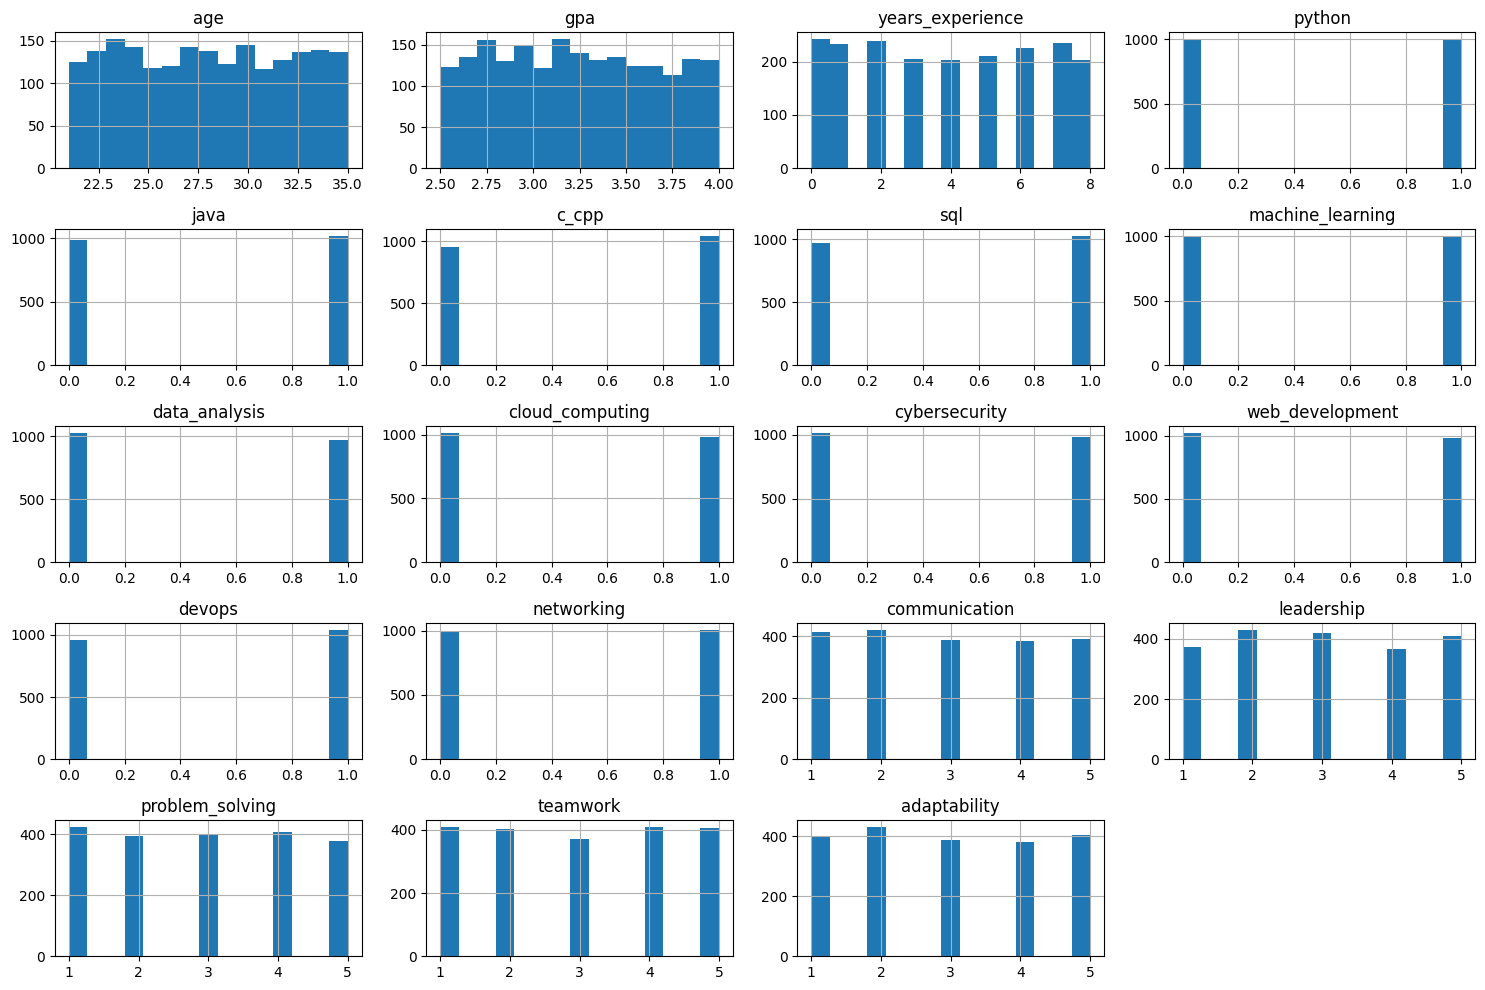

In [ ]:
# ==========================================
# Step 15: Numerical Features Distribution
# ==========================================

df[numerical_cols].hist(figsize=(15,10), bins=15)

plt.tight_layout()
plt.show()

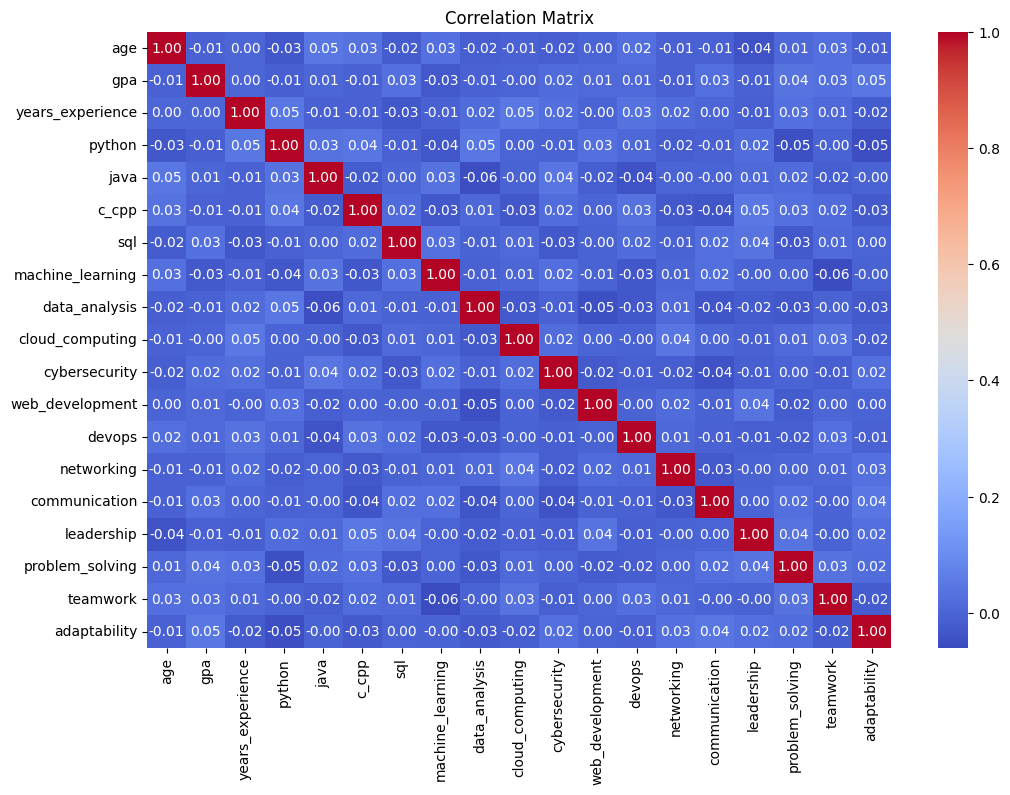

In [ ]:
# ==========================================
# Step 16: Correlation Matrix
# ==========================================

plt.figure(figsize=(12,8))

sns.heatmap(
    df[numerical_cols].corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")
plt.show()

In [ ]:

print(df.shape)

df.head()

(2000, 25)


,age,gender,degree_level,field_of_study,gpa,years_experience,python,java,c_cpp,sql,machine_learning,data_analysis,cloud_computing,cybersecurity,web_development,devops,networking,communication,leadership,problem_solving,teamwork,adaptability,recommended_job_1,recommended_job_2,recommended_job_3
0,34,Male,Bachelor,Data Science,3.46,3,1,0,1,1,0,1,1,1,0,1,0,5,3,2,4,4,Business Intelligence Analyst,Software Engineer,Cloud Engineer
1,30,Female,PhD,Data Science,3.72,4,1,0,0,1,0,1,0,0,0,1,0,2,1,1,5,1,Business Intelligence Analyst,DevOps Engineer,AI Researcher
2,31,Female,PhD,Cybersecurity,2.70,8,1,0,0,1,1,1,0,0,0,0,0,4,2,1,3,2,Business Intelligence Analyst,Machine Learning Engineer,Data Scientist
3,25,Female,Bachelor,Data Science,2.50,1,0,1,0,0,1,1,1,0,1,0,0,2,5,5,1,5,Software Engineer,Cloud Engineer,Backend Developer
4,24,Female,Bachelor,Software Engineering,3.95,7,0,0,0,0,0,1,1,0,0,0,1,2,3,3,1,5,Cloud Engineer,AI Researcher,Security Engineer


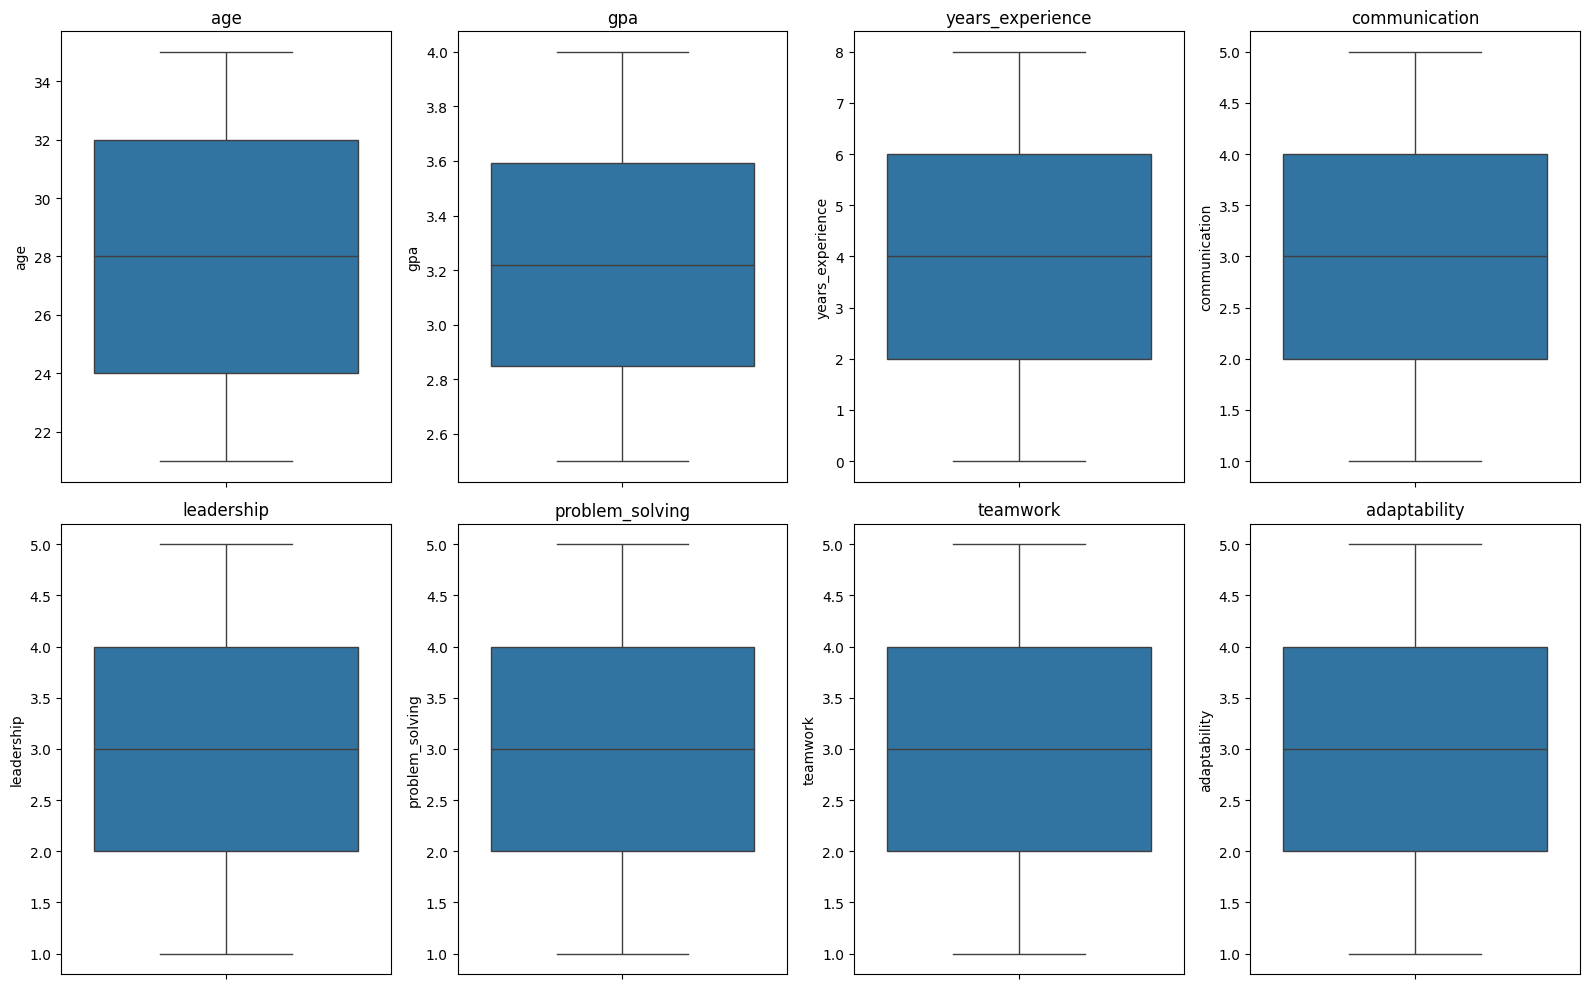

In [ ]:
# ==========================================
# Step 20: Boxplots for Numerical Features
# ==========================================

numerical_features = [
    'age',
    'gpa',
    'years_experience',
    'communication',
    'leadership',
    'problem_solving',
    'teamwork',
    'adaptability'
]

plt.figure(figsize=(16,10))

for i, feature in enumerate(numerical_features):
    plt.subplot(2,4,i+1)
    sns.boxplot(y=df[feature])
    plt.title(feature)

plt.tight_layout()
plt.show()

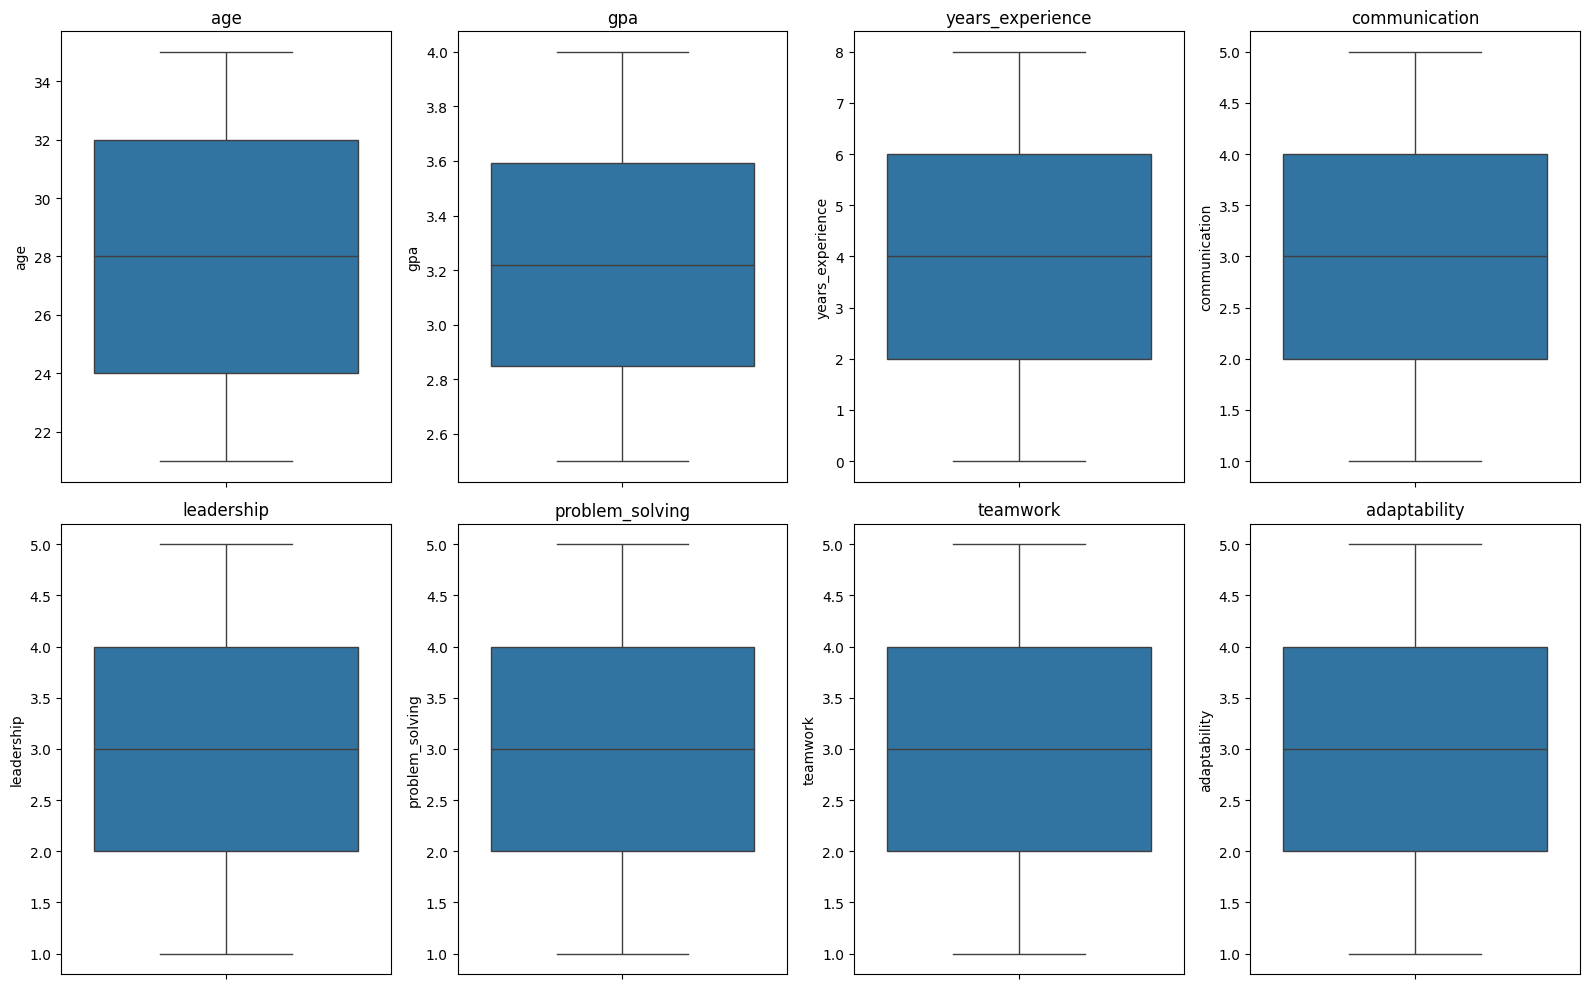

In [ ]:
# ==========================================
# Step 20: Boxplots for Numerical Features
# ==========================================

numerical_features = [
    'age',
    'gpa',
    'years_experience',
    'communication',
    'leadership',
    'problem_solving',
    'teamwork',
    'adaptability'
]

plt.figure(figsize=(16,10))

for i, feature in enumerate(numerical_features):
    plt.subplot(2,4,i+1)
    sns.boxplot(y=df[feature])
    plt.title(feature)

plt.tight_layout()
plt.show()

In [ ]:
# ==========================================
# Step 21: Outlier Detection using IQR
# ==========================================

for feature in numerical_features:

    Q1 = df[feature].quantile(0.25)
    Q3 = df[feature].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[(df[feature] < lower) | (df[feature] > upper)]

    print(f"{feature}: {len(outliers)} outliers")

age: 0 outliers
gpa: 0 outliers
years_experience: 0 outliers
communication: 0 outliers
leadership: 0 outliers
problem_solving: 0 outliers
teamwork: 0 outliers
adaptability: 0 outliers


In [ ]:
# ==========================================
# Save Current Dataset
# ==========================================

df.to_csv("career_dataset_before_encoding.csv", index=False)

print("Dataset saved successfully!")

Dataset saved successfully!


In [ ]:
from google.colab import files

files.download("career_dataset_before_encoding.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Class Distribution (recommended_job_1)

recommended_job_1
Software Engineer                852
Business Intelligence Analyst    400
Machine Learning Engineer        367
Cloud Engineer                   139
AI Researcher                     81
DevOps Engineer                   71
Cybersecurity Analyst             36
Frontend Developer                16
Security Engineer                 13
Backend Developer                 11
Full Stack Developer               7
Data Scientist                     7
Name: count, dtype: int64

Percentage Distribution

recommended_job_1
Software Engineer                42.60
Business Intelligence Analyst    20.00
Machine Learning Engineer        18.35
Cloud Engineer                    6.95
AI Researcher                     4.05
DevOps Engineer                   3.55
Cybersecurity Analyst             1.80
Frontend Developer                0.80
Security Engineer                 0.65
Backend Developer                 0.55
Full Stack Developer              0.35

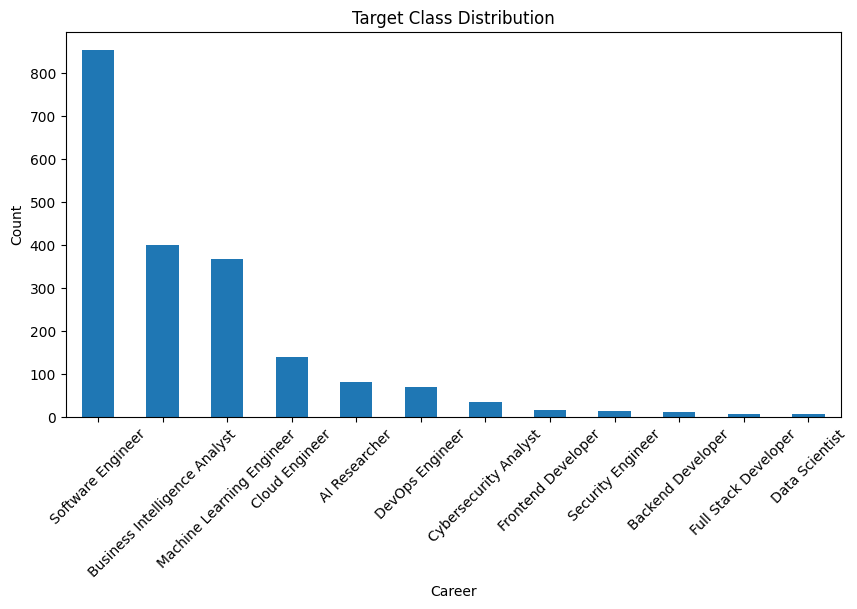

In [ ]:
# ==========================================
# Check Class Imbalance
# ==========================================

import matplotlib.pyplot as plt

print("Class Distribution (recommended_job_1)\n")
print(df["recommended_job_1"].value_counts())

print("\nPercentage Distribution\n")
print(round(df["recommended_job_1"].value_counts(normalize=True)*100,2))

plt.figure(figsize=(10,5))
df["recommended_job_1"].value_counts().plot(kind="bar")
plt.title("Target Class Distribution")
plt.xlabel("Career")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

In [ ]:
# ==========================================
# Check Data Types
# ==========================================

print(df.dtypes)

print("\nColumns having object datatype:\n")

object_cols = df.select_dtypes(include="object").columns

print(object_cols)

age                    int64
gender                object
degree_level          object
field_of_study        object
gpa                  float64
years_experience       int64
python                 int64
java                   int64
c_cpp                  int64
sql                    int64
machine_learning       int64
data_analysis          int64
cloud_computing        int64
cybersecurity          int64
web_development        int64
devops                 int64
networking             int64
communication          int64
leadership             int64
problem_solving        int64
teamwork               int64
adaptability           int64
recommended_job_1     object
recommended_job_2     object
recommended_job_3     object
experience_level      object
dtype: object

Columns having object datatype:

Index(['gender', 'degree_level', 'field_of_study', 'recommended_job_1',
       'recommended_job_2', 'recommended_job_3', 'experience_level'],
      dtype='object')


In [ ]:
# ==========================================
# LOAD PREPROCESSED DATASET
# ==========================================

from google.colab import files
import pandas as pd

# Upload dataset
uploaded = files.upload()

# Read uploaded CSV file
file_name = list(uploaded.keys())[0]
df = pd.read_csv(file_name)

# Display basic information
print("Dataset Loaded Successfully!")
print("Dataset Shape:", df.shape)

print("\nFirst 5 Rows:")
display(df.head())

Saving Career_Path_Prediction_Preprocessed.csv to Career_Path_Prediction_Preprocessed.csv
Dataset Loaded Successfully!
Dataset Shape: (2000, 32)

First 5 Rows:


,age,gpa,years_experience,python,java,c_cpp,sql,machine_learning,data_analysis,cloud_computing,...,gender_Male,degree_level_Master,degree_level_PhD,field_of_study_Computer Science,field_of_study_Cybersecurity,field_of_study_Data Science,field_of_study_Software Engineering,experience_level_Experienced,experience_level_Expert,experience_level_Intermediate
0,34,3.46,3,1,0,1,1,0,1,1,...,1,0,0,0,0,1,0,0,0,1
1,30,3.72,4,1,0,0,1,0,1,0,...,0,0,1,0,0,1,0,1,0,0
2,31,2.70,8,1,0,0,1,1,1,0,...,0,0,1,0,1,0,0,0,1,0
3,25,2.50,1,0,1,0,0,1,1,1,...,0,0,0,0,0,1,0,0,0,0
4,24,3.95,7,0,0,0,0,0,1,1,...,0,0,0,0,0,0,1,0,1,0


In [ ]:
# ==========================================
# CHECK NUMERICAL FEATURE RANGES
# ==========================================

print("=" * 70)
print("NUMERICAL FEATURE SUMMARY")
print("=" * 70)

display(df.describe().T)

print("\nDataset Shape:", df.shape)

NUMERICAL FEATURE SUMMARY


,count,mean,std,min,25%,50%,75%,max
age,2000.0,27.991500,4.347284,21.0,24.00,28.00,32.0000,35.0
gpa,2000.0,3.231695,0.429938,2.5,2.85,3.22,3.5925,4.0
years_experience,2000.0,3.913500,2.611212,0.0,2.00,4.00,6.0000,8.0
python,2000.0,0.501500,0.500123,0.0,0.00,1.00,1.0000,1.0
java,2000.0,0.509000,0.500044,0.0,0.00,1.00,1.0000,1.0
c_cpp,2000.0,0.522000,0.499641,0.0,0.00,1.00,1.0000,1.0
sql,2000.0,0.513500,0.499943,0.0,0.00,1.00,1.0000,1.0
machine_learning,2000.0,0.502000,0.500121,0.0,0.00,1.00,1.0000,1.0
data_analysis,2000.0,0.486000,0.499929,0.0,0.00,0.00,1.0000,1.0
cloud_computing,2000.0,0.492500,0.500069,0.0,0.00,0.00,1.0000,1.0



Dataset Shape: (2000, 32)


In [ ]:
# ==========================================
# Separate Features (X) and Target (y)
# ==========================================

# Features (Independent Variables)
X = df.drop(columns=["recommended_job_1"])

# Target (Dependent Variable)
y = df["recommended_job_1"]

print("=" * 60)
print("FEATURES AND TARGET")
print("=" * 60)

print(f"Feature Matrix Shape : {X.shape}")
print(f"Target Vector Shape  : {y.shape}")

print("\nTarget Class Distribution:\n")
print(y.value_counts().sort_index())

FEATURES AND TARGET
Feature Matrix Shape : (2000, 31)
Target Vector Shape  : (2000,)

Target Class Distribution:

recommended_job_1
0      81
1      11
2     400
3     139
4      36
5       7
6      71
7      16
8       7
9     367
10     13
11    852
Name: count, dtype: int64


In [ ]:
# ==========================================
# Train-Test Split
# ==========================================

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("=" * 60)
print("TRAIN-TEST SPLIT")
print("=" * 60)

print("Training Features :", X_train.shape)
print("Testing Features  :", X_test.shape)

print("Training Target   :", y_train.shape)
print("Testing Target    :", y_test.shape)

print("\nTraining Class Distribution:")
print(y_train.value_counts().sort_index())

print("\nTesting Class Distribution:")
print(y_test.value_counts().sort_index())

TRAIN-TEST SPLIT
Training Features : (1600, 31)
Testing Features  : (400, 31)
Training Target   : (1600,)
Testing Target    : (400,)

Training Class Distribution:
recommended_job_1
0      65
1       9
2     320
3     111
4      29
5       5
6      57
7      13
8       5
9     294
10     10
11    682
Name: count, dtype: int64

Testing Class Distribution:
recommended_job_1
0      16
1       2
2      80
3      28
4       7
5       2
6      14
7       3
8       2
9      73
10      3
11    170
Name: count, dtype: int64


In [ ]:
# ==========================================
# Feature Scaling
# ==========================================

from sklearn.preprocessing import StandardScaler

# Initialize the scaler
scaler = StandardScaler()

# Fit on training data and transform both datasets
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("=" * 60)
print("FEATURE SCALING COMPLETED")
print("=" * 60)

print("Scaled Training Features Shape :", X_train_scaled.shape)
print("Scaled Testing Features Shape  :", X_test_scaled.shape)

print("\nFirst 5 rows of Scaled Training Data:")
print(X_train_scaled[:5])

FEATURE SCALING COMPLETED
Scaled Training Features Shape : (1600, 31)
Scaled Testing Features Shape  : (400, 31)

First 5 rows of Scaled Training Data:
[[-0.4649526  -0.79272245  0.78912439  1.00250313  0.97043679  0.94761986
  -1.02148066  1.00125078 -0.9619725  -0.99376941  0.996257    1.02660376
   0.97043679 -0.99252792 -1.38922957 -1.41206479  0.72946607  0.69827475
  -1.386615    1.32825439  0.6506306   1.02660376 -0.726757    1.3991019
  -0.5204324  -0.50195237  2.08594596 -0.50585272 -0.51363709  1.41090546
  -0.54364194]
 [ 0.91524065 -1.56135243  1.5575961   1.00250313  0.97043679  0.94761986
   0.97897106  1.00125078 -0.9619725  -0.99376941 -1.00375706 -0.97408566
   0.97043679  1.00752834  0.03882524  0.00888091  1.43469006 -0.00218895
   0.71630822  1.32825439  0.6506306   1.02660376 -0.726757   -0.71474422
  -0.5204324  -0.50195237 -0.4793988   1.97686    -0.51363709  1.41090546
  -0.54364194]
 [-0.00488818  0.81441296  1.17336025  1.00250313  0.97043679  0.94761986
   0.

In [ ]:
# ==========================================
# Logistic Regression Model
# ==========================================

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# Create Logistic Regression model
lr_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

# Train the model
lr_model.fit(X_train_scaled, y_train)

# Make predictions
y_pred_lr = lr_model.predict(X_test_scaled)

# Calculate Accuracy
accuracy = accuracy_score(y_test, y_pred_lr)

print("=" * 60)
print("LOGISTIC REGRESSION RESULTS")
print("=" * 60)

print(f"Accuracy : {accuracy:.4f}")

LOGISTIC REGRESSION RESULTS
Accuracy : 0.9575


In [ ]:
# ==========================================
# Logistic Regression Performance Table
# ==========================================

import pandas as pd
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

# Calculate performance metrics
accuracy = accuracy_score(y_test, y_pred_lr)
precision = precision_score(y_test, y_pred_lr, average='weighted')
recall = recall_score(y_test, y_pred_lr, average='weighted')
f1 = f1_score(y_test, y_pred_lr, average='weighted')

# Create performance table
performance_table = pd.DataFrame({
    "Performance Metric": [
        "Accuracy",
        "Precision (Weighted)",
        "Recall (Weighted)",
        "F1-Score (Weighted)"
    ],
    "Value (%)": [
        round(accuracy * 100, 2),
        round(precision * 100, 2),
        round(recall * 100, 2),
        round(f1 * 100, 2)
    ]
})

print("=" * 60)
print("LOGISTIC REGRESSION PERFORMANCE TABLE")
print("=" * 60)

display(performance_table)

LOGISTIC REGRESSION PERFORMANCE TABLE


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


,Performance Metric,Value (%)
0,Accuracy,95.75
1,Precision (Weighted),94.32
2,Recall (Weighted),95.75
3,F1-Score (Weighted),94.96


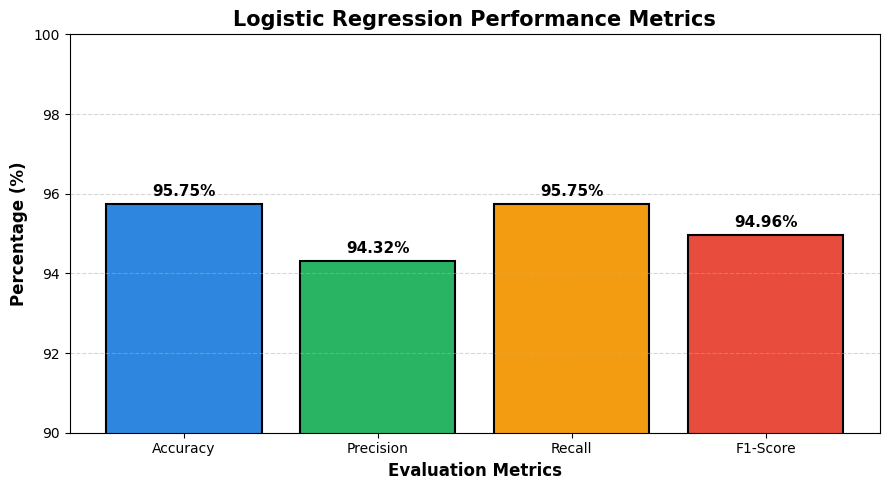

In [ ]:
# ==========================================
# Logistic Regression Performance Bar Chart
# ==========================================

import matplotlib.pyplot as plt

# Performance Metrics
metrics = ["Accuracy", "Precision", "Recall", "F1-Score"]
values = [95.75, 94.32, 95.75, 94.96]

# Different colors for each metric
colors = ["#2E86DE", "#28B463", "#F39C12", "#E74C3C"]

plt.figure(figsize=(9,5))

bars = plt.bar(metrics, values, color=colors, edgecolor="black", linewidth=1.5)

# Value labels
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2,
             height + 0.2,
             f"{height:.2f}%",
             ha='center',
             fontsize=11,
             fontweight='bold')

plt.ylim(90, 100)

plt.title("Logistic Regression Performance Metrics",
          fontsize=15,
          fontweight="bold")

plt.xlabel("Evaluation Metrics",
           fontsize=12,
           fontweight="bold")

plt.ylabel("Percentage (%)",
           fontsize=12,
           fontweight="bold")

plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()

plt.show()

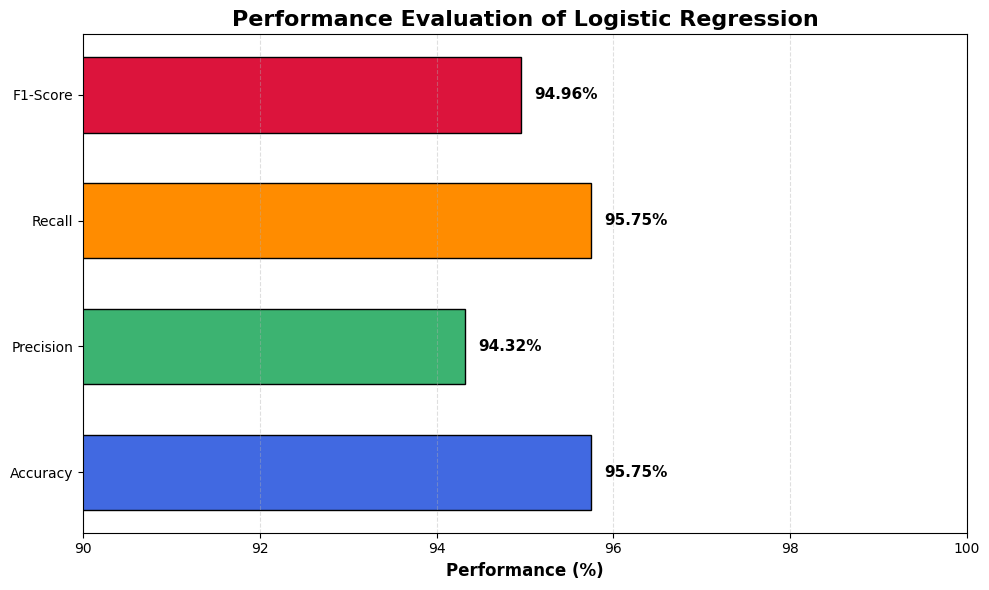

In [ ]:
# ==========================================
# Dissertation-Quality Performance Chart
# ==========================================

import matplotlib.pyplot as plt

metrics = ["Accuracy", "Precision", "Recall", "F1-Score"]
values = [95.75, 94.32, 95.75, 94.96]

colors = ["royalblue", "mediumseagreen", "darkorange", "crimson"]

plt.figure(figsize=(10,6))

bars = plt.barh(metrics, values,
                color=colors,
                edgecolor="black",
                height=0.6)

for bar in bars:
    plt.text(bar.get_width()+0.15,
             bar.get_y()+bar.get_height()/2,
             f"{bar.get_width():.2f}%",
             va="center",
             fontsize=11,
             fontweight="bold")

plt.xlim(90,100)

plt.xlabel("Performance (%)",
           fontsize=12,
           fontweight="bold")

plt.title("Performance Evaluation of Logistic Regression",
          fontsize=16,
          fontweight="bold")

plt.grid(axis="x", linestyle="--", alpha=0.4)

plt.tight_layout()

plt.show()

In [ ]:
# ==========================================
# Logistic Regression ROC-AUC Score
# ==========================================

from sklearn.metrics import roc_auc_score

# Predict class probabilities
y_prob_lr = lr_model.predict_proba(X_test_scaled)

# Calculate Multiclass ROC-AUC Score
roc_auc = roc_auc_score(
    y_test,
    y_prob_lr,
    multi_class="ovr",
    average="weighted"
)

print("=" * 60)
print("LOGISTIC REGRESSION ROC-AUC SCORE")
print("=" * 60)

print(f"ROC-AUC Score : {roc_auc:.4f}")

LOGISTIC REGRESSION ROC-AUC SCORE
ROC-AUC Score : 0.9966


In [ ]:
# ==========================================
# Logistic Regression 10-Fold Cross Validation
# ==========================================

from sklearn.model_selection import cross_val_score
import numpy as np

# Perform 10-Fold Cross Validation
cv_scores = cross_val_score(
    LogisticRegression(max_iter=1000, random_state=42),
    X_train_scaled,
    y_train,
    cv=10,
    scoring="accuracy"
)

print("=" * 60)
print("10-FOLD CROSS VALIDATION")
print("=" * 60)

print("Cross Validation Scores:\n")
print(np.round(cv_scores, 4))

print("\nAverage CV Accuracy : {:.4f}".format(cv_scores.mean()))
print("Standard Deviation  : {:.4f}".format(cv_scores.std()))

/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 5 members, which is less than n_splits=10.
  warnings.warn(


10-FOLD CROSS VALIDATION
Cross Validation Scores:

[0.95   0.9625 0.9062 0.9438 0.95   0.9125 0.9312 0.95   0.9562 0.9625]

Average CV Accuracy : 0.9425
Standard Deviation  : 0.0187


In [ ]:
# ==========================================
# Random Forest Model
# ==========================================

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# Create Random Forest model
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

# Train the model
rf_model.fit(X_train, y_train)

# Make predictions
y_pred_rf = rf_model.predict(X_test)

# Calculate Accuracy
rf_accuracy = accuracy_score(y_test, y_pred_rf)

print("=" * 60)
print("RANDOM FOREST RESULTS")
print("=" * 60)

print(f"Accuracy : {rf_accuracy:.4f}")

RANDOM FOREST RESULTS
Accuracy : 0.9375


In [ ]:
# ==========================================
# Random Forest Evaluation Metrics
# ==========================================

from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

# Calculate Evaluation Metrics
rf_precision = precision_score(y_test, y_pred_rf, average='weighted', zero_division=0)
rf_recall = recall_score(y_test, y_pred_rf, average='weighted', zero_division=0)
rf_f1 = f1_score(y_test, y_pred_rf, average='weighted', zero_division=0)

print("=" * 60)
print("RANDOM FOREST PERFORMANCE")
print("=" * 60)

print(f"Accuracy : {rf_accuracy:.4f}")
print(f"Precision: {rf_precision:.4f}")
print(f"Recall   : {rf_recall:.4f}")
print(f"F1-Score : {rf_f1:.4f}")

print("\nClassification Report\n")
print(classification_report(y_test, y_pred_rf, zero_division=0))

RANDOM FOREST PERFORMANCE
Accuracy : 0.9375
Precision: 0.9094
Recall   : 0.9375
F1-Score : 0.9215

Classification Report

              precision    recall  f1-score   support

           0       0.93      0.81      0.87        16
           1       0.00      0.00      0.00         2
           2       0.96      1.00      0.98        80
           3       0.96      0.93      0.95        28
           4       1.00      0.57      0.73         7
           5       0.00      0.00      0.00         2
           6       0.77      0.71      0.74        14
           7       0.00      0.00      0.00         3
           8       0.00      0.00      0.00         2
           9       0.95      0.99      0.97        73
          10       0.00      0.00      0.00         3
          11       0.93      1.00      0.96       170

    accuracy                           0.94       400
   macro avg       0.54      0.50      0.52       400
weighted avg       0.91      0.94      0.92       400



RANDOM FOREST PERFORMANCE TABLE


,Performance Metric,Value (%)
0,Accuracy,93.75
1,Precision (Weighted),90.94
2,Recall (Weighted),93.75
3,F1-Score (Weighted),92.15


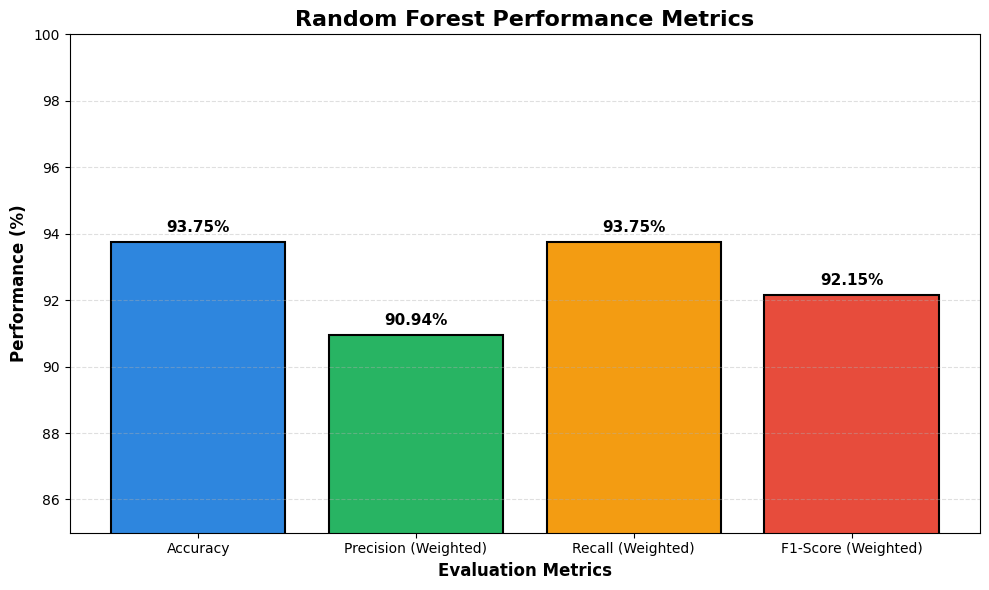

In [ ]:
# ==========================================
# Random Forest Performance Table
# ==========================================

import pandas as pd
import matplotlib.pyplot as plt

# Create Performance Table
rf_performance = pd.DataFrame({
    "Performance Metric": [
        "Accuracy",
        "Precision (Weighted)",
        "Recall (Weighted)",
        "F1-Score (Weighted)"
    ],
    "Value (%)": [
        round(rf_accuracy * 100, 2),
        round(rf_precision * 100, 2),
        round(rf_recall * 100, 2),
        round(rf_f1 * 100, 2)
    ]
})

print("=" * 60)
print("RANDOM FOREST PERFORMANCE TABLE")
print("=" * 60)

display(rf_performance)


print("\n\n")


# ==========================================
# Random Forest Performance Graph
# ==========================================

metrics = rf_performance["Performance Metric"]
values = rf_performance["Value (%)"]

colors = [
    "#2E86DE",   # Blue
    "#28B463",   # Green
    "#F39C12",   # Orange
    "#E74C3C"    # Red
]

plt.figure(figsize=(10,6))

bars = plt.bar(
    metrics,
    values,
    color=colors,
    edgecolor="black",
    linewidth=1.5
)

# Add value labels
for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.3,
        f"{bar.get_height():.2f}%",
        ha="center",
        fontsize=11,
        fontweight="bold"
    )

plt.ylim(85,100)

plt.title(
    "Random Forest Performance Metrics",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel(
    "Evaluation Metrics",
    fontsize=12,
    fontweight="bold"
)

plt.ylabel(
    "Performance (%)",
    fontsize=12,
    fontweight="bold"
)

plt.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()

plt.show()

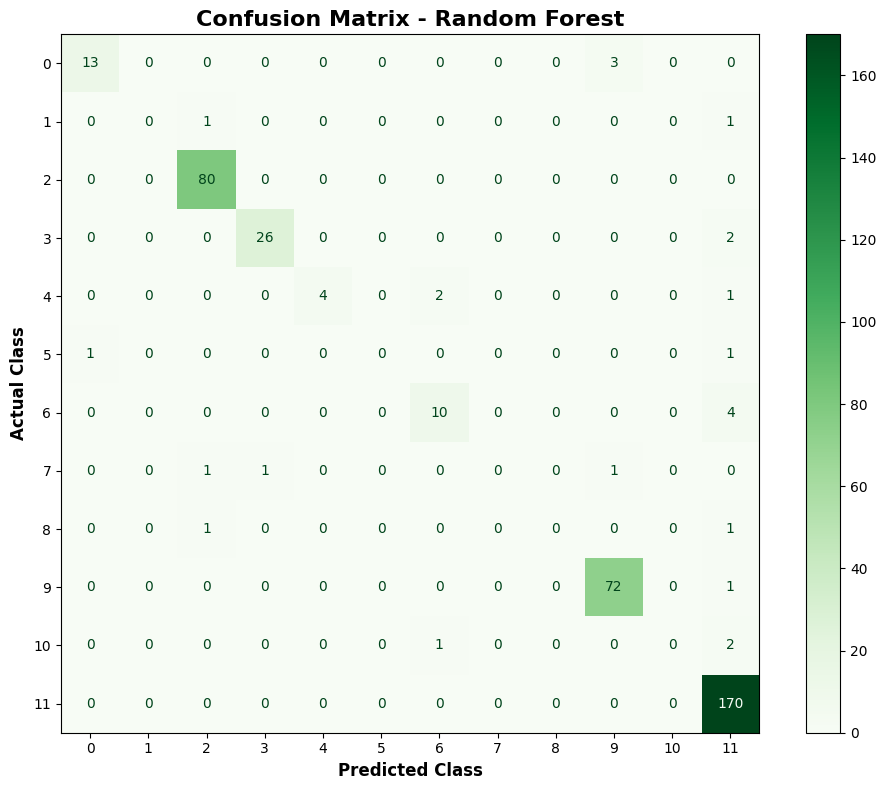

In [ ]:
# ==========================================
# Random Forest Confusion Matrix
# ==========================================

import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

# Generate Confusion Matrix
cm_rf = confusion_matrix(y_test, y_pred_rf)

# Plot Confusion Matrix
fig, ax = plt.subplots(figsize=(10,8))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_rf,
    display_labels=rf_model.classes_
)

disp.plot(
    cmap="Greens",
    values_format="d",
    ax=ax,
    colorbar=True
)

plt.title(
    "Confusion Matrix - Random Forest",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel(
    "Predicted Class",
    fontsize=12,
    fontweight="bold"
)

plt.ylabel(
    "Actual Class",
    fontsize=12,
    fontweight="bold"
)

plt.grid(False)
plt.tight_layout()

plt.show()

In [ ]:
# ==========================================
# Random Forest ROC-AUC Score
# ==========================================

from sklearn.metrics import roc_auc_score

# Predict class probabilities
y_prob_rf = rf_model.predict_proba(X_test)

# Calculate Multiclass ROC-AUC Score
rf_roc_auc = roc_auc_score(
    y_test,
    y_prob_rf,
    multi_class="ovr",
    average="weighted"
)

print("=" * 60)
print("RANDOM FOREST ROC-AUC SCORE")
print("=" * 60)

print(f"ROC-AUC Score : {rf_roc_auc:.4f}")

RANDOM FOREST ROC-AUC SCORE
ROC-AUC Score : 0.9938


In [ ]:
# ==========================================
# Random Forest 10-Fold Cross Validation
# ==========================================

from sklearn.model_selection import cross_val_score
import numpy as np

# Perform 10-Fold Cross Validation
rf_cv_scores = cross_val_score(
    RandomForestClassifier(
        n_estimators=100,
        random_state=42
    ),
    X_train,
    y_train,
    cv=10,
    scoring="accuracy"
)

print("=" * 60)
print("RANDOM FOREST 10-FOLD CROSS VALIDATION")
print("=" * 60)

print("Cross Validation Scores:\n")
print(np.round(rf_cv_scores, 4))

print("\nAverage CV Accuracy : {:.4f}".format(rf_cv_scores.mean()))
print("Standard Deviation  : {:.4f}".format(rf_cv_scores.std()))

/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 5 members, which is less than n_splits=10.
  warnings.warn(


RANDOM FOREST 10-FOLD CROSS VALIDATION
Cross Validation Scores:

[0.9438 0.9688 0.9375 0.9562 0.9438 0.9375 0.925  0.9438 0.975  0.95  ]

Average CV Accuracy : 0.9481
Standard Deviation  : 0.0143


In [ ]:
# ==========================================
# Upload Dataset
# ==========================================

from google.colab import files
import pandas as pd

uploaded = files.upload()

Saving Career_Path_Prediction_Preprocessed.csv to Career_Path_Prediction_Preprocessed.csv


In [ ]:
# ==========================================
# Load Dataset
# ==========================================

file_name = list(uploaded.keys())[0]
df = pd.read_csv(file_name)

print("=" * 60)
print("DATASET LOADED SUCCESSFULLY")
print("=" * 60)

print("Dataset Shape :", df.shape)

display(df.head())


DATASET LOADED SUCCESSFULLY
Dataset Shape : (2000, 32)


,age,gpa,years_experience,python,java,c_cpp,sql,machine_learning,data_analysis,cloud_computing,...,gender_Male,degree_level_Master,degree_level_PhD,field_of_study_Computer Science,field_of_study_Cybersecurity,field_of_study_Data Science,field_of_study_Software Engineering,experience_level_Experienced,experience_level_Expert,experience_level_Intermediate
0,34,3.46,3,1,0,1,1,0,1,1,...,1,0,0,0,0,1,0,0,0,1
1,30,3.72,4,1,0,0,1,0,1,0,...,0,0,1,0,0,1,0,1,0,0
2,31,2.70,8,1,0,0,1,1,1,0,...,0,0,1,0,1,0,0,0,1,0
3,25,2.50,1,0,1,0,0,1,1,1,...,0,0,0,0,0,1,0,0,0,0
4,24,3.95,7,0,0,0,0,0,1,1,...,0,0,0,0,0,0,1,0,1,0


In [ ]:
# ==========================================
# Separate Features and Target
# ==========================================

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Features
X = df.drop(columns=["recommended_job_1"])

# Target
y = df["recommended_job_1"]

print("=" * 60)
print("FEATURES AND TARGET")
print("=" * 60)

print("Feature Matrix Shape :", X.shape)
print("Target Vector Shape  :", y.shape)

print("\nTarget Class Distribution:\n")
print(y.value_counts().sort_index())

# ==========================================
# Train-Test Split
# ==========================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("\n" + "=" * 60)
print("TRAIN-TEST SPLIT")
print("=" * 60)

print("Training Features :", X_train.shape)
print("Testing Features  :", X_test.shape)

print("Training Target   :", y_train.shape)
print("Testing Target    :", y_test.shape)

# ==========================================
# Feature Scaling
# ==========================================

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\n" + "=" * 60)
print("FEATURE SCALING COMPLETED")
print("=" * 60)

print("Scaled Training Shape :", X_train_scaled.shape)
print("Scaled Testing Shape  :", X_test_scaled.shape)

FEATURES AND TARGET
Feature Matrix Shape : (2000, 31)
Target Vector Shape  : (2000,)

Target Class Distribution:

recommended_job_1
0      81
1      11
2     400
3     139
4      36
5       7
6      71
7      16
8       7
9     367
10     13
11    852
Name: count, dtype: int64

TRAIN-TEST SPLIT
Training Features : (1600, 31)
Testing Features  : (400, 31)
Training Target   : (1600,)
Testing Target    : (400,)

FEATURE SCALING COMPLETED
Scaled Training Shape : (1600, 31)
Scaled Testing Shape  : (400, 31)


In [ ]:
!pip install xgboost

In [ ]:
# ==========================================
# XGBoost Model
# ==========================================

from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score

# Encode target labels
label_encoder = LabelEncoder()

y_train_encoded = label_encoder.fit_transform(y_train)
y_test_encoded = label_encoder.transform(y_test)

# Create XGBoost model
xgb_model = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    objective="multi:softprob",
    eval_metric="mlogloss",
    random_state=42
)

# Train the model
xgb_model.fit(X_train, y_train_encoded)

# Predict
y_pred_xgb = xgb_model.predict(X_test)

# Accuracy
xgb_accuracy = accuracy_score(y_test_encoded, y_pred_xgb)

print("=" * 60)
print("XGBOOST RESULTS")
print("=" * 60)
print(f"Accuracy : {xgb_accuracy:.4f}")

XGBOOST RESULTS
Accuracy : 0.9750


In [ ]:
# ==========================================
# XGBoost Evaluation Metrics
# ==========================================

from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

# Calculate Evaluation Metrics
xgb_precision = precision_score(
    y_test_encoded,
    y_pred_xgb,
    average='weighted',
    zero_division=0
)

xgb_recall = recall_score(
    y_test_encoded,
    y_pred_xgb,
    average='weighted',
    zero_division=0
)

xgb_f1 = f1_score(
    y_test_encoded,
    y_pred_xgb,
    average='weighted',
    zero_division=0
)

print("=" * 60)
print("XGBOOST PERFORMANCE")
print("=" * 60)

print(f"Accuracy : {xgb_accuracy:.4f}")
print(f"Precision: {xgb_precision:.4f}")
print(f"Recall   : {xgb_recall:.4f}")
print(f"F1-Score : {xgb_f1:.4f}")

print("\nClassification Report\n")

print(
    classification_report(
        y_test_encoded,
        y_pred_xgb,
        zero_division=0
    )
)

XGBOOST PERFORMANCE
Accuracy : 0.9750
Precision: 0.9639
Recall   : 0.9750
F1-Score : 0.9690

Classification Report

              precision    recall  f1-score   support

           0       1.00      0.88      0.93        16
           1       0.00      0.00      0.00         2
           2       0.99      1.00      0.99        80
           3       0.90      1.00      0.95        28
           4       1.00      1.00      1.00         7
           5       0.00      0.00      0.00         2
           6       0.88      1.00      0.93        14
           7       0.67      0.67      0.67         3
           8       0.00      0.00      0.00         2
           9       1.00      1.00      1.00        73
          10       0.67      0.67      0.67         3
          11       0.99      1.00      1.00       170

    accuracy                           0.97       400
   macro avg       0.67      0.68      0.68       400
weighted avg       0.96      0.97      0.97       400



In [ ]:
# ==========================================
# XGBoost Performance Table
# ==========================================

import pandas as pd

# Create Performance Table
xgb_performance = pd.DataFrame({
    "Performance Metric": [
        "Accuracy",
        "Precision (Weighted)",
        "Recall (Weighted)",
        "F1-Score (Weighted)"
    ],
    "Value (%)": [
        round(xgb_accuracy * 100, 2),
        round(xgb_precision * 100, 2),
        round(xgb_recall * 100, 2),
        round(xgb_f1 * 100, 2)
    ]
})

print("=" * 60)
print("XGBOOST PERFORMANCE TABLE")
print("=" * 60)

display(xgb_performance)

print("\n\n")

XGBOOST PERFORMANCE TABLE


,Performance Metric,Value (%)
0,Accuracy,97.50
1,Precision (Weighted),96.39
2,Recall (Weighted),97.50
3,F1-Score (Weighted),96.90


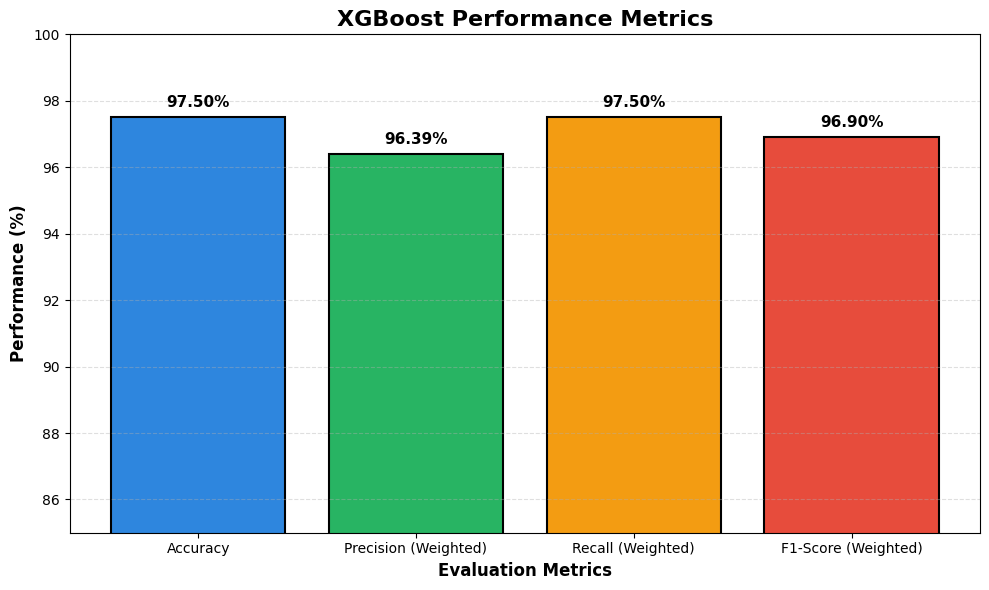

In [ ]:
# ==========================================
# XGBoost Performance Graph
# ==========================================

import matplotlib.pyplot as plt

metrics = xgb_performance["Performance Metric"]
values = xgb_performance["Value (%)"]

colors = [
    "#2E86DE",   # Blue
    "#28B463",   # Green
    "#F39C12",   # Orange
    "#E74C3C"    # Red
]

plt.figure(figsize=(10,6))

bars = plt.bar(
    metrics,
    values,
    color=colors,
    edgecolor="black",
    linewidth=1.5
)

# Add value labels
for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.3,
        f"{bar.get_height():.2f}%",
        ha="center",
        fontsize=11,
        fontweight="bold"
    )

plt.ylim(85,100)

plt.title(
    "XGBoost Performance Metrics",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel(
    "Evaluation Metrics",
    fontsize=12,
    fontweight="bold"
)

plt.ylabel(
    "Performance (%)",
    fontsize=12,
    fontweight="bold"
)

plt.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()

plt.show()

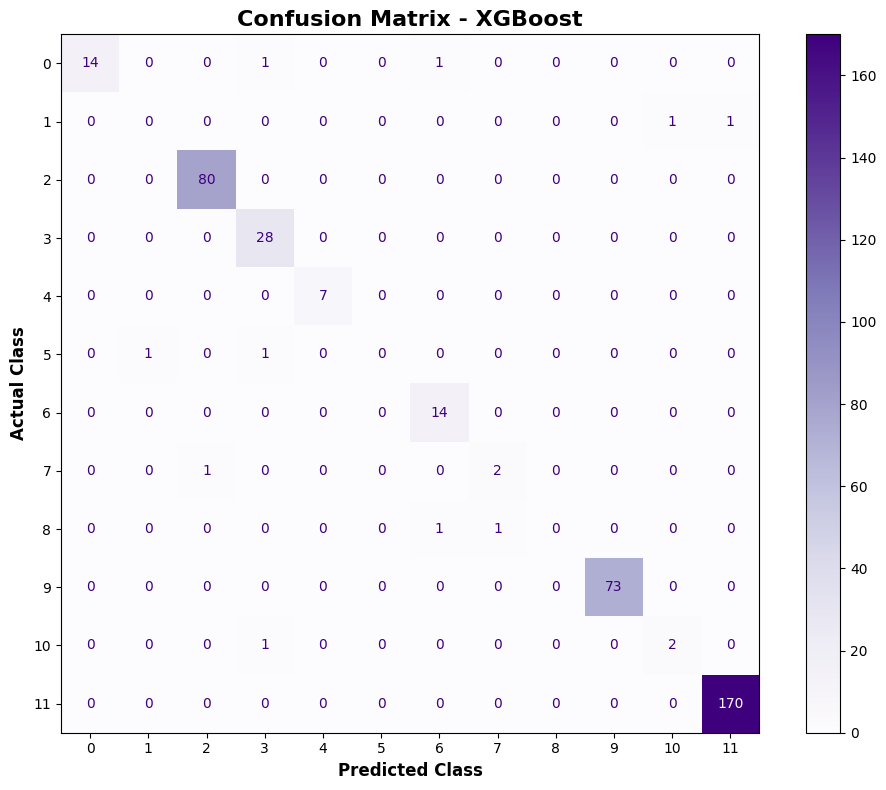

In [ ]:
# ==========================================
# XGBoost Confusion Matrix
# ==========================================

import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

# Generate Confusion Matrix
cm_xgb = confusion_matrix(y_test_encoded, y_pred_xgb)

# Plot Confusion Matrix
fig, ax = plt.subplots(figsize=(10,8))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_xgb,
    display_labels=label_encoder.classes_
)

disp.plot(
    cmap="Purples",
    values_format="d",
    ax=ax,
    colorbar=True
)

plt.title(
    "Confusion Matrix - XGBoost",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel(
    "Predicted Class",
    fontsize=12,
    fontweight="bold"
)

plt.ylabel(
    "Actual Class",
    fontsize=12,
    fontweight="bold"
)

plt.grid(False)
plt.tight_layout()

plt.show()


In [ ]:
# ==========================================
# XGBoost ROC-AUC Score
# ==========================================

from sklearn.metrics import roc_auc_score

# Predict class probabilities
y_prob_xgb = xgb_model.predict_proba(X_test)

# Calculate Multiclass ROC-AUC Score
xgb_roc_auc = roc_auc_score(
    y_test_encoded,
    y_prob_xgb,
    multi_class="ovr",
    average="weighted"
)

print("=" * 60)
print("XGBOOST ROC-AUC SCORE")
print("=" * 60)

print(f"ROC-AUC Score : {xgb_roc_auc:.4f}")

XGBOOST ROC-AUC SCORE
ROC-AUC Score : 0.9994


In [ ]:
# ==========================================
# XGBoost 10-Fold Cross Validation
# ==========================================

from sklearn.model_selection import cross_val_score
import numpy as np

# Perform 10-Fold Cross Validation
xgb_cv_scores = cross_val_score(
    XGBClassifier(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=6,
        objective="multi:softprob",
        eval_metric="mlogloss",
        random_state=42
    ),
    X_train,
    y_train_encoded,
    cv=10,
    scoring="accuracy"
)

print("=" * 60)
print("XGBOOST 10-FOLD CROSS VALIDATION")
print("=" * 60)

print("Cross Validation Scores:\n")
print(np.round(xgb_cv_scores, 4))


print("\nAverage CV Accuracy : {:.4f}".format(xgb_cv_scores.mean()))
print("Standard Deviation  : {:.4f}".format(xgb_cv_scores.std()))

/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 5 members, which is less than n_splits=10.
  warnings.warn(


XGBOOST 10-FOLD CROSS VALIDATION
Cross Validation Scores:

[0.9688 0.9812 0.95   0.9812 0.975  0.9562 0.975  0.9625 0.9688 0.9812]

Average CV Accuracy : 0.9700
Standard Deviation  : 0.0104


In [2]:
# ==========================================
# STEP 2: PREPARE FINAL MODEL FOR STREAMLIT
# ==========================================

# ==========================================
# 1. Upload Dataset
# ==========================================

from google.colab import files
import pandas as pd
import numpy as np

uploaded = files.upload()

file_name = list(uploaded.keys())[0]

df = pd.read_csv(file_name)

print("=" * 70)
print("DATASET LOADED SUCCESSFULLY")
print("=" * 70)

print("Dataset Shape :", df.shape)

display(df.head())


Saving New Dataset.csv to New Dataset.csv
DATASET LOADED SUCCESSFULLY
Dataset Shape : (2000, 25)


,age,gender,degree_level,field_of_study,gpa,years_experience,python,java,c_cpp,sql,...,devops,networking,communication,leadership,problem_solving,teamwork,adaptability,recommended_job_1,recommended_job_2,recommended_job_3
0,34,Male,Bachelor,Data Science,3.46,3,1,0,1,1,...,1,0,5,3,2,4,4,Business Intelligence Analyst,Software Engineer,Cloud Engineer
1,30,Female,PhD,Data Science,3.72,4,1,0,0,1,...,1,0,2,1,1,5,1,Business Intelligence Analyst,DevOps Engineer,AI Researcher
2,31,Female,PhD,Cybersecurity,2.70,8,1,0,0,1,...,0,0,4,2,1,3,2,Business Intelligence Analyst,Machine Learning Engineer,Data Scientist
3,25,Female,Bachelor,Data Science,2.50,1,0,1,0,0,...,0,0,2,5,5,1,5,Software Engineer,Cloud Engineer,Backend Developer
4,24,Female,Bachelor,Software Engineering,3.95,7,0,0,0,0,...,0,1,2,3,3,1,5,Cloud Engineer,AI Researcher,Security Engineer


In [3]:
# ==========================================
# 2. Separate Features and Target
# ==========================================

target_column = "recommended_job_1"

X = df.drop(columns=[
    "recommended_job_1",
    "recommended_job_2",
    "recommended_job_3"
])

y = df[target_column]

print("=" * 70)
print("FEATURES AND TARGET")
print("=" * 70)

print("Feature Shape :", X.shape)
print("Target Shape  :", y.shape)

print("\nTarget Classes:")
print(y.value_counts())

FEATURES AND TARGET
Feature Shape : (2000, 22)
Target Shape  : (2000,)

Target Classes:
recommended_job_1
Software Engineer                852
Business Intelligence Analyst    400
Machine Learning Engineer        367
Cloud Engineer                   139
AI Researcher                     81
DevOps Engineer                   71
Cybersecurity Analyst             36
Frontend Developer                16
Security Engineer                 13
Backend Developer                 11
Full Stack Developer               7
Data Scientist                     7
Name: count, dtype: int64


In [4]:
# ==========================================
# 3. Encode Categorical Features
# ==========================================

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

categorical_features = X.select_dtypes(
    include=["object"]
).columns.tolist()

numerical_features = X.select_dtypes(
    exclude=["object"]
).columns.tolist()

print("Categorical Features:")
print(categorical_features)

print("\nNumerical Features:")
print(numerical_features)

preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            ),
            categorical_features
        ),
        (
            "numerical",
            "passthrough",
            numerical_features
        )
    ]
)

X_processed = preprocessor.fit_transform(X)

print("\nProcessed Feature Shape:", X_processed.shape)

Categorical Features:
['gender', 'degree_level', 'field_of_study']

Numerical Features:
['age', 'gpa', 'years_experience', 'python', 'java', 'c_cpp', 'sql', 'machine_learning', 'data_analysis', 'cloud_computing', 'cybersecurity', 'web_development', 'devops', 'networking', 'communication', 'leadership', 'problem_solving', 'teamwork', 'adaptability']

Processed Feature Shape: (2000, 29)


In [5]:
# ==========================================
# 4. Create Feature Names
# ==========================================

encoded_feature_names = preprocessor.named_transformers_[
    "categorical"
].get_feature_names_out(categorical_features)

feature_columns = list(encoded_feature_names) + numerical_features

X_processed = pd.DataFrame(
    X_processed,
    columns=feature_columns,
    index=X.index
)

print("=" * 70)
print("FEATURE ENGINEERING COMPLETED")
print("=" * 70)

print("Final Feature Shape :", X_processed.shape)

display(X_processed.head())

FEATURE ENGINEERING COMPLETED
Final Feature Shape : (2000, 29)


,gender_Female,gender_Male,degree_level_Bachelor,degree_level_Master,degree_level_PhD,field_of_study_AI,field_of_study_Computer Science,field_of_study_Cybersecurity,field_of_study_Data Science,field_of_study_Software Engineering,...,cloud_computing,cybersecurity,web_development,devops,networking,communication,leadership,problem_solving,teamwork,adaptability
0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,1.0,1.0,0.0,1.0,0.0,5.0,3.0,2.0,4.0,4.0
1,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,1.0,0.0,2.0,1.0,1.0,5.0,1.0
2,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,4.0,2.0,1.0,3.0,2.0
3,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,1.0,0.0,1.0,0.0,0.0,2.0,5.0,5.0,1.0,5.0
4,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,1.0,0.0,0.0,0.0,1.0,2.0,3.0,3.0,1.0,5.0


In [6]:
# ==========================================
# 5. Encode Target Classes
# ==========================================

from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

y_encoded = label_encoder.fit_transform(y)

print("=" * 70)
print("TARGET ENCODING")
print("=" * 70)

print("Career Classes:")
for number, career in enumerate(label_encoder.classes_):
    print(number, ":", career)

TARGET ENCODING
Career Classes:
0 : AI Researcher
1 : Backend Developer
2 : Business Intelligence Analyst
3 : Cloud Engineer
4 : Cybersecurity Analyst
5 : Data Scientist
6 : DevOps Engineer
7 : Frontend Developer
8 : Full Stack Developer
9 : Machine Learning Engineer
10 : Security Engineer
11 : Software Engineer


In [7]:
# ==========================================
# 6. Train-Test Split
# ==========================================

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_processed,
    y_encoded,
    test_size=0.20,
    random_state=42,
    stratify=y_encoded
)

print("=" * 70)
print("TRAIN-TEST SPLIT")
print("=" * 70)

print("Training Features :", X_train.shape)
print("Testing Features  :", X_test.shape)

print("Training Target   :", y_train.shape)
print("Testing Target    :", y_test.shape)

TRAIN-TEST SPLIT
Training Features : (1600, 29)
Testing Features  : (400, 29)
Training Target   : (1600,)
Testing Target    : (400,)


In [8]:
# ==========================================
# 7. Train Final XGBoost Model
# ==========================================

!pip install -q xgboost

from xgboost import XGBClassifier

final_xgb_model = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    objective="multi:softprob",
    eval_metric="mlogloss",
    random_state=42
)

final_xgb_model.fit(
    X_train,
    y_train
)

print("=" * 70)
print("FINAL XGBOOST MODEL TRAINED")
print("=" * 70)

print("Model: XGBoost")
print("Number of Estimators:", 100)
print("Learning Rate:", 0.1)
print("Maximum Depth:", 6)

FINAL XGBOOST MODEL TRAINED
Model: XGBoost
Number of Estimators: 100
Learning Rate: 0.1
Maximum Depth: 6


In [9]:
# ==========================================
# 8. Evaluate Final XGBoost Model
# ==========================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report
)

y_pred = final_xgb_model.predict(X_test)

y_prob = final_xgb_model.predict_proba(X_test)

accuracy = accuracy_score(y_test, y_pred)

precision = precision_score(
    y_test,
    y_pred,
    average="weighted",
    zero_division=0
)

recall = recall_score(
    y_test,
    y_pred,
    average="weighted",
    zero_division=0
)

f1 = f1_score(
    y_test,
    y_pred,
    average="weighted",
    zero_division=0
)

roc_auc = roc_auc_score(
    y_test,
    y_prob,
    multi_class="ovr",
    average="weighted"
)

print("=" * 70)
print("FINAL XGBOOST PERFORMANCE")
print("=" * 70)

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-Score : {f1:.4f}")
print(f"ROC-AUC  : {roc_auc:.4f}")

print("\nClassification Report\n")

print(
    classification_report(
        y_test,
        y_pred,
        target_names=label_encoder.classes_,
        zero_division=0
    )
)

FINAL XGBOOST PERFORMANCE
Accuracy : 0.9600
Precision: 0.9391
Recall   : 0.9600
F1-Score : 0.9478
ROC-AUC  : 0.9737

Classification Report

                               precision    recall  f1-score   support

                AI Researcher       1.00      0.88      0.93        16
            Backend Developer       0.00      0.00      0.00         2
Business Intelligence Analyst       0.94      1.00      0.97        80
               Cloud Engineer       0.96      0.96      0.96        28
        Cybersecurity Analyst       1.00      1.00      1.00         7
               Data Scientist       0.00      0.00      0.00         2
              DevOps Engineer       1.00      1.00      1.00        14
           Frontend Developer       0.00      0.00      0.00         3
         Full Stack Developer       0.00      0.00      0.00         2
    Machine Learning Engineer       0.95      0.99      0.97        73
            Security Engineer       1.00      0.33      0.50         3
       

In [10]:
# ==========================================
# 9. Save Model and Preprocessing Objects
# ==========================================

import pickle

# XGBoost model
with open("xgboost_model.pkl", "wb") as file:
    pickle.dump(final_xgb_model, file)

# Preprocessing pipeline
with open("preprocessor.pkl", "wb") as file:
    pickle.dump(preprocessor, file)

# Label encoder
with open("label_encoder.pkl", "wb") as file:
    pickle.dump(label_encoder, file)

# Exact feature columns
with open("feature_columns.pkl", "wb") as file:
    pickle.dump(feature_columns, file)

print("=" * 70)
print("MODEL ARTIFACTS SAVED")
print("=" * 70)

print("xgboost_model.pkl")
print("preprocessor.pkl")
print("label_encoder.pkl")
print("feature_columns.pkl")

MODEL ARTIFACTS SAVED
xgboost_model.pkl
preprocessor.pkl
label_encoder.pkl
feature_columns.pkl


In [12]:
# ==========================================
# 10. Career Mapping
# ==========================================

career_mapping = {
    int(index): career
    for index, career in enumerate(label_encoder.classes_)
}

print("=" * 70)
print("CAREER MAPPING")
print("=" * 70)

for key, value in career_mapping.items():
    print(key, ":", value)

with open("career_mapping.pkl", "wb") as file:
    pickle.dump(career_mapping, file)

CAREER MAPPING
0 : AI Researcher
1 : Backend Developer
2 : Business Intelligence Analyst
3 : Cloud Engineer
4 : Cybersecurity Analyst
5 : Data Scientist
6 : DevOps Engineer
7 : Frontend Developer
8 : Full Stack Developer
9 : Machine Learning Engineer
10 : Security Engineer
11 : Software Engineer


In [13]:
# ==========================================
# 11. Generate Required Skills
# ==========================================

skill_columns = [
    "python",
    "java",
    "c_cpp",
    "sql",
    "machine_learning",
    "data_analysis",
    "cloud_computing",
    "cybersecurity",
    "web_development",
    "devops",
    "networking"
]

skill_names = {
    "python": "Python",
    "java": "Java",
    "c_cpp": "C/C++",
    "sql": "SQL",
    "machine_learning": "Machine Learning",
    "data_analysis": "Data Analysis",
    "cloud_computing": "Cloud Computing",
    "cybersecurity": "Cybersecurity",
    "web_development": "Web Development",
    "devops": "DevOps",
    "networking": "Networking"
}

required_skills = {}

for career in df["recommended_job_1"].unique():

    career_data = df[
        df["recommended_job_1"] == career
    ]

    skills = []

    for skill in skill_columns:

        if skill in career_data.columns:

            skill_average = career_data[skill].mean()

            if skill_average >= 0.50:
                skills.append(
                    skill_names[skill]
                )

    required_skills[career] = skills

print("=" * 70)
print("REQUIRED SKILLS GENERATED")
print("=" * 70)

for career, skills in required_skills.items():
    print("\n", career)
    print(skills)

with open("required_skills.pkl", "wb") as file:
    pickle.dump(required_skills, file)

REQUIRED SKILLS GENERATED

 Business Intelligence Analyst
['C/C++', 'SQL', 'Data Analysis']

 Software Engineer
['Java', 'C/C++', 'Cybersecurity', 'DevOps', 'Networking']

 Cloud Engineer
['Cloud Computing', 'Web Development', 'Networking']

 Machine Learning Engineer
['Python', 'Java', 'C/C++', 'Machine Learning', 'Web Development', 'DevOps']

 AI Researcher
['Python', 'Java', 'C/C++', 'SQL', 'Machine Learning', 'Web Development', 'DevOps', 'Networking']

 Backend Developer
['Python', 'Java', 'C/C++', 'SQL', 'Data Analysis', 'DevOps']

 DevOps Engineer
['Web Development', 'DevOps', 'Networking']

 Security Engineer
['Python', 'Data Analysis', 'Networking']

 Cybersecurity Analyst
['Cybersecurity', 'Web Development', 'Networking']

 Frontend Developer
['Web Development', 'Networking']

 Full Stack Developer
['Java', 'SQL', 'Machine Learning', 'Web Development', 'DevOps']

 Data Scientist
['Python', 'Java', 'SQL', 'Machine Learning', 'Data Analysis', 'Cloud Computing', 'Web Development'

In [14]:
# ==========================================
# 12. Skill Recommendation Mapping
# ==========================================

skill_recommendations = {}

for career, skills in required_skills.items():

    skill_recommendations[career] = {}

    for skill in skills:

        skill_recommendations[career][skill] = (
            f"Improve your {skill} skills through "
            f"practical projects, structured learning "
            f"and regular practice."
        )

with open(
    "skill_recommendations.pkl",
    "wb"
) as file:

    pickle.dump(
        skill_recommendations,
        file
    )

print("=" * 70)
print("SKILL RECOMMENDATIONS SAVED")
print("=" * 70)

SKILL RECOMMENDATIONS SAVED


In [15]:
# ==========================================
# 13. Create Streamlit Model Package
# ==========================================

streamlit_files = [
    "xgboost_model.pkl",
    "preprocessor.pkl",
    "label_encoder.pkl",
    "feature_columns.pkl",
    "career_mapping.pkl",
    "required_skills.pkl",
    "skill_recommendations.pkl"
]

print("=" * 70)
print("FILES REQUIRED FOR STREAMLIT")
print("=" * 70)

for file_name in streamlit_files:
    print(file_name)


FILES REQUIRED FOR STREAMLIT
xgboost_model.pkl
preprocessor.pkl
label_encoder.pkl
feature_columns.pkl
career_mapping.pkl
required_skills.pkl
skill_recommendations.pkl


In [16]:
# ==========================================
# 14. Download Streamlit Files
# ==========================================

from google.colab import files

for file_name in streamlit_files:

    files.download(file_name)

print("=" * 70)
print("ALL STREAMLIT FILES READY")
print("=" * 70)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

ALL STREAMLIT FILES READY


In [18]:
# ==========================================
# STEP 2.1: UPLOAD AND LOAD SAVED MODEL FILES
# ==========================================

from google.colab import files
import pickle

uploaded = files.upload()

print("=" * 70)
print("FILES UPLOADED")
print("=" * 70)

for file_name in uploaded.keys():
    print(file_name)

# ==========================================
# Load XGBoost Model
# ==========================================

with open("xgboost_model.pkl", "rb") as file:
    xgboost_model = pickle.load(file)

# ==========================================
# Load Preprocessor
# ==========================================

with open("preprocessor.pkl", "rb") as file:
    preprocessor = pickle.load(file)

# ==========================================
# Load Label Encoder
# ==========================================

with open("label_encoder.pkl", "rb") as file:
    label_encoder = pickle.load(file)

# ==========================================
# Load Feature Columns
# ==========================================

with open("feature_columns.pkl", "rb") as file:
    feature_columns = pickle.load(file)

# ==========================================
# Verify Loaded Files
# ==========================================

print("\n" + "=" * 70)
print("SAVED MODEL FILES LOADED SUCCESSFULLY")
print("=" * 70)

print("XGBoost Model      :", type(xgboost_model).__name__)
print("Preprocessor       :", type(preprocessor).__name__)
print("Label Encoder      :", type(label_encoder).__name__)
print("Number of Features :", len(feature_columns))

print("\nCareer Classes:")

for i, career in enumerate(label_encoder.classes_):
    print(f"{i}: {career}")

Saving career_mapping.pkl to career_mapping (1).pkl
Saving feature_columns (1).pkl to feature_columns (1).pkl
Saving label_encoder (1).pkl to label_encoder (1).pkl
Saving preprocessor.pkl to preprocessor (1).pkl
Saving required_skills (1).pkl to required_skills (1).pkl
Saving skill_recommendations (1).pkl to skill_recommendations (1).pkl
Saving xgboost_model (1).pkl to xgboost_model (1).pkl
FILES UPLOADED
career_mapping (1).pkl
feature_columns (1).pkl
label_encoder (1).pkl
preprocessor (1).pkl
required_skills (1).pkl
skill_recommendations (1).pkl
xgboost_model (1).pkl

SAVED MODEL FILES LOADED SUCCESSFULLY
XGBoost Model      : XGBClassifier
Preprocessor       : ColumnTransformer
Label Encoder      : LabelEncoder
Number of Features : 29

Career Classes:
0: AI Researcher
1: Backend Developer
2: Business Intelligence Analyst
3: Cloud Engineer
4: Cybersecurity Analyst
5: Data Scientist
6: DevOps Engineer
7: Frontend Developer
8: Full Stack Developer
9: Machine Learning Engineer
10: Securit

In [27]:
# ==========================================
# FINAL STREAMLIT FILES
# ==========================================

import pickle
from google.colab import files

# ==========================================
# Save Final XGBoost Model
# ==========================================

with open("xgboost_model_Final.pkl", "wb") as file:
    pickle.dump(xgboost_model, file)

# ==========================================
# Save Final Preprocessor
# ==========================================

with open("preprocessor_Final.pkl", "wb") as file:
    pickle.dump(preprocessor, file)

# ==========================================
# Save Final Label Encoder
# ==========================================

with open("label_encoder_Final.pkl", "wb") as file:
    pickle.dump(label_encoder, file)

# ==========================================
# Save Final Feature Columns
# ==========================================

with open("feature_columns_Final.pkl", "wb") as file:
    pickle.dump(feature_columns, file)

# ==========================================
# Save Final Career Mapping
# ==========================================

with open("career_mapping_Final.pkl", "wb") as file:
    pickle.dump(career_mapping, file)

# ==========================================
# Save Final Required Skills
# ==========================================

with open("required_skills_Final.pkl", "wb") as file:
    pickle.dump(required_skills, file)

# ==========================================
# Save Final Skill Recommendations
# ==========================================

with open("skill_recommendations_Final.pkl", "wb") as file:
    pickle.dump(skill_recommendations, file)

# ==========================================
# Final Files List
# ==========================================

final_files = [
    "xgboost_model_Final.pkl",
    "preprocessor_Final.pkl",
    "label_encoder_Final.pkl",
    "feature_columns_Final.pkl",
    "career_mapping_Final.pkl",
    "required_skills_Final.pkl",
    "skill_recommendations_Final.pkl"
]

print("=" * 80)
print("FINAL STREAMLIT FILES CREATED")
print("=" * 80)

for file_name in final_files:
    print(file_name)

# ==========================================
# Download All Final Files
# ==========================================

print("\n" + "=" * 80)
print("DOWNLOADING FINAL STREAMLIT FILES")
print("=" * 80)

for file_name in final_files:
    files.download(file_name)

print("\n" + "=" * 80)
print("ALL FINAL STREAMLIT FILES DOWNLOADED")
print("=" * 80)

FINAL STREAMLIT FILES CREATED
xgboost_model_Final.pkl
preprocessor_Final.pkl
label_encoder_Final.pkl
feature_columns_Final.pkl
career_mapping_Final.pkl
required_skills_Final.pkl
skill_recommendations_Final.pkl

DOWNLOADING FINAL STREAMLIT FILES


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


ALL FINAL STREAMLIT FILES DOWNLOADED


In [29]:
# ==========================================
# STREAMLIT SETUP
# INSTALL LIBRARIES AND UPLOAD FINAL FILES
# ==========================================

!pip install -q streamlit xgboost pyngrok

from google.colab import files
import os

# ==========================================
# Upload Final Streamlit Files
# ==========================================

uploaded = files.upload()

required_files = [
    "xgboost_model_Final.pkl",
    "preprocessor_Final.pkl",
    "label_encoder_Final.pkl",
    "feature_columns_Final.pkl",
    "career_mapping_Final.pkl",
    "required_skills_Final.pkl",
    "skill_recommendations_Final.pkl"
]

print("=" * 80)
print("UPLOADED FILES")
print("=" * 80)

for file_name in uploaded.keys():
    print(file_name)

# ==========================================
# Verify Required Files
# ==========================================

print("\n" + "=" * 80)
print("FILE VERIFICATION")
print("=" * 80)

missing_files = []

for file_name in required_files:

    if os.path.exists(file_name):
        print(f"✓ {file_name}")

    else:
        print(f"✗ {file_name}")
        missing_files.append(file_name)

# ==========================================
# Verification Result
# ==========================================

if len(missing_files) == 0:

    print("\n" + "=" * 80)
    print("ALL REQUIRED STREAMLIT FILES ARE READY")
    print("=" * 80)

else:

    print("\n" + "=" * 80)
    print("MISSING FILES")
    print("=" * 80)

    for file_name in missing_files:
        print("-", file_name)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.5/10.5 MB 25.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 40.7 MB/s eta 0:00:00


Saving career_mapping_Final.pkl to career_mapping_Final (1).pkl
Saving feature_columns_Final.pkl to feature_columns_Final (1).pkl
Saving label_encoder_Final.pkl to label_encoder_Final (1).pkl
Saving preprocessor_Final.pkl to preprocessor_Final (1).pkl
Saving required_skills_Final.pkl to required_skills_Final (1).pkl
Saving skill_recommendations_Final.pkl to skill_recommendations_Final (1).pkl
Saving xgboost_model_Final.pkl to xgboost_model_Final (1).pkl
UPLOADED FILES
career_mapping_Final (1).pkl
feature_columns_Final (1).pkl
label_encoder_Final (1).pkl
preprocessor_Final (1).pkl
required_skills_Final (1).pkl
skill_recommendations_Final (1).pkl
xgboost_model_Final (1).pkl

FILE VERIFICATION
✓ xgboost_model_Final.pkl
✓ preprocessor_Final.pkl
✓ label_encoder_Final.pkl
✓ feature_columns_Final.pkl
✓ career_mapping_Final.pkl
✓ required_skills_Final.pkl
✓ skill_recommendations_Final.pkl

ALL REQUIRED STREAMLIT FILES ARE READY


In [30]:
%%writefile app.py

# ==========================================
# CAREER PATH PREDICTION SYSTEM
# Streamlit Application
# ==========================================

import streamlit as st
import pandas as pd
import pickle


# ==========================================
# PAGE CONFIGURATION
# ==========================================

st.set_page_config(
    page_title="Career Path Prediction System",
    page_icon="🎯",
    layout="wide"
)


# ==========================================
# LOAD MODEL FILES
# ==========================================

@st.cache_resource
def load_model_files():

    with open("xgboost_model_Final.pkl", "rb") as file:
        model = pickle.load(file)

    with open("preprocessor_Final.pkl", "rb") as file:
        preprocessor = pickle.load(file)

    with open("label_encoder_Final.pkl", "rb") as file:
        label_encoder = pickle.load(file)

    with open("feature_columns_Final.pkl", "rb") as file:
        feature_columns = pickle.load(file)

    with open("career_mapping_Final.pkl", "rb") as file:
        career_mapping = pickle.load(file)

    with open("required_skills_Final.pkl", "rb") as file:
        required_skills = pickle.load(file)

    with open("skill_recommendations_Final.pkl", "rb") as file:
        skill_recommendations = pickle.load(file)

    return (
        model,
        preprocessor,
        label_encoder,
        feature_columns,
        career_mapping,
        required_skills,
        skill_recommendations
    )


(
    model,
    preprocessor,
    label_encoder,
    feature_columns,
    career_mapping,
    required_skills,
    skill_recommendations
) = load_model_files()


# ==========================================
# APPLICATION TITLE
# ==========================================

st.title("Career Path Prediction System")

st.write(
    "A Machine Learning-Based Framework for Predicting "
    "Developer Career Paths and Recommending Skill Development Pathways"
)

st.divider()


# ==========================================
# USER PROFILE
# ==========================================

st.header("1. Personal and Academic Information")

col1, col2, col3 = st.columns(3)

with col1:

    age = st.number_input(
        "Age",
        min_value=15,
        max_value=70,
        value=25,
        step=1
    )

with col2:

    gender = st.selectbox(
        "Gender",
        [
            "Male",
            "Female"
        ]
    )

with col3:

    degree_level = st.selectbox(
        "Degree Level",
        [
            "High School",
            "Associate",
            "Bachelor",
            "Master",
            "PhD"
        ]
    )


col1, col2, col3 = st.columns(3)

with col1:

    field_of_study = st.selectbox(
        "Field of Study",
        [
            "Computer Science",
            "Software Engineering",
            "Information Technology",
            "Data Science",
            "Cybersecurity",
            "Artificial Intelligence",
            "Information Systems",
            "Computer Engineering"
        ]
    )

with col2:

    gpa = st.number_input(
        "GPA",
        min_value=0.0,
        max_value=4.0,
        value=3.0,
        step=0.01
    )

with col3:

    years_experience = st.number_input(
        "Years of Experience",
        min_value=0,
        max_value=40,
        value=1,
        step=1
    )


# ==========================================
# TECHNICAL SKILLS
# ==========================================

st.header("2. Technical Skills")

st.write(
    "Select the technical skills that you currently possess."
)

skill_col1, skill_col2, skill_col3 = st.columns(3)

with skill_col1:

    python = st.checkbox("Python")

    java = st.checkbox("Java")

    c_cpp = st.checkbox("C/C++")

    sql = st.checkbox("SQL")


with skill_col2:

    machine_learning = st.checkbox(
        "Machine Learning"
    )

    data_analysis = st.checkbox(
        "Data Analysis"
    )

    cloud_computing = st.checkbox(
        "Cloud Computing"
    )

    cybersecurity = st.checkbox(
        "Cybersecurity"
    )


with skill_col3:

    web_development = st.checkbox(
        "Web Development"
    )

    devops = st.checkbox(
        "DevOps"
    )

    networking = st.checkbox(
        "Networking"
    )


# ==========================================
# SOFT SKILLS
# ==========================================

st.header("3. Soft Skills")

soft_col1, soft_col2, soft_col3, soft_col4 = st.columns(4)

with soft_col1:

    communication = st.slider(
        "Communication",
        min_value=1,
        max_value=5,
        value=3
    )

with soft_col2:

    leadership = st.slider(
        "Leadership",
        min_value=1,
        max_value=5,
        value=3
    )

with soft_col3:

    problem_solving = st.slider(
        "Problem Solving",
        min_value=1,
        max_value=5,
        value=3
    )

with soft_col4:

    teamwork = st.slider(
        "Teamwork",
        min_value=1,
        max_value=5,
        value=3
    )


adaptability = st.slider(
    "Adaptability",
    min_value=1,
    max_value=5,
    value=3
)


# ==========================================
# PREDICTION BUTTON
# ==========================================

st.divider()

predict_button = st.button(
    "Predict My Career Path",
    type="primary",
    use_container_width=True
)


# ==========================================
# CAREER PREDICTION
# ==========================================

if predict_button:

    # ==========================================
    # Create User Input DataFrame
    # ==========================================

    user_data = pd.DataFrame({

        "age": [age],

        "gender": [gender],

        "degree_level": [degree_level],

        "field_of_study": [field_of_study],

        "gpa": [gpa],

        "years_experience": [
            years_experience
        ],

        "python": [
            int(python)
        ],

        "java": [
            int(java)
        ],

        "c_cpp": [
            int(c_cpp)
        ],

        "sql": [
            int(sql)
        ],

        "machine_learning": [
            int(machine_learning)
        ],

        "data_analysis": [
            int(data_analysis)
        ],

        "cloud_computing": [
            int(cloud_computing)
        ],

        "cybersecurity": [
            int(cybersecurity)
        ],

        "web_development": [
            int(web_development)
        ],

        "devops": [
            int(devops)
        ],

        "networking": [
            int(networking)
        ],

        "communication": [
            communication
        ],

        "leadership": [
            leadership
        ],

        "problem_solving": [
            problem_solving
        ],

        "teamwork": [
            teamwork
        ],

        "adaptability": [
            adaptability
        ]
    })


    # ==========================================
    # Preprocess User Input
    # ==========================================

    processed_input = preprocessor.transform(
        user_data
    )


    # ==========================================
    # Career Prediction
    # ==========================================

    predicted_class = model.predict(
        processed_input
    )

    predicted_career = label_encoder.inverse_transform(
        predicted_class
    )[0]


    # ==========================================
    # Prediction Probability
    # ==========================================

    probabilities = model.predict_proba(
        processed_input
    )[0]

    prediction_probability = (
        probabilities[predicted_class[0]] * 100
    )


    # ==========================================
    # Display Career Prediction
    # ==========================================

    st.success(
        f"Predicted Career: {predicted_career}"
    )

    st.metric(
        "Prediction Confidence",
        f"{prediction_probability:.2f}%"
    )


    # ==========================================
    # Current User Skills
    # ==========================================

    skill_names = {

        "python": "Python",

        "java": "Java",

        "c_cpp": "C/C++",

        "sql": "SQL",

        "machine_learning":
            "Machine Learning",

        "data_analysis":
            "Data Analysis",

        "cloud_computing":
            "Cloud Computing",

        "cybersecurity":
            "Cybersecurity",

        "web_development":
            "Web Development",

        "devops": "DevOps",

        "networking": "Networking"
    }


    selected_skills = {

        "python": python,

        "java": java,

        "c_cpp": c_cpp,

        "sql": sql,

        "machine_learning":
            machine_learning,

        "data_analysis":
            data_analysis,

        "cloud_computing":
            cloud_computing,

        "cybersecurity":
            cybersecurity,

        "web_development":
            web_development,

        "devops": devops,

        "networking": networking
    }


    current_skills = []

    for skill, selected in selected_skills.items():

        if selected:

            current_skills.append(
                skill_names[skill]
            )


    # ==========================================
    # Required Skills
    # ==========================================

    career_required_skills = required_skills.get(
        predicted_career,
        []
    )


    # ==========================================
    # Skill Matching
    # ==========================================

    matched_skills = [

        skill

        for skill in career_required_skills

        if skill in current_skills
    ]


    skill_gap = [

        skill

        for skill in career_required_skills

        if skill not in current_skills
    ]


    # ==========================================
    # Skills Section
    # ==========================================

    st.divider()

    st.header("4. Career Skill Analysis")

    col1, col2 = st.columns(2)

    with col1:

        st.subheader("Required Skills")

        if career_required_skills:

            for skill in career_required_skills:

                st.write(
                    f"• {skill}"
                )

        else:

            st.write(
                "No required skills found."
            )


    with col2:

        st.subheader("Your Current Skills")

        if current_skills:

            for skill in current_skills:

                st.write(
                    f"• {skill}"
                )

        else:

            st.write(
                "No technical skills selected."
            )


    # ==========================================
    # Matched Skills
    # ==========================================

    st.divider()

    st.subheader("Matched Skills")

    if matched_skills:

        for skill in matched_skills:

            st.write(
                f"✓ {skill}"
            )

    else:

        st.info(
            "No required skills are currently matched."
        )


    # ==========================================
    # Skill Gap
    # ==========================================

    st.subheader("Skill Gaps")

    if skill_gap:

        for skill in skill_gap:

            st.write(
                f"• {skill}"
            )

    else:

        st.success(
            "No skill gaps identified. "
            "You already possess all required skills "
            "for the predicted career."
        )


    # ==========================================
    # Personalized Recommendations
    # ==========================================

    st.divider()

    st.header(
        "5. Personalized Skill Recommendations"
    )


    if skill_gap:

        for skill in skill_gap:

            st.subheader(skill)

            career_recommendations = (
                skill_recommendations.get(
                    predicted_career,
                    {}
                )
            )

            recommendation = (
                career_recommendations.get(
                    skill,
                    f"Improve your {skill} skills "
                    "through practical projects, "
                    "structured learning and regular practice."
                )
            )

            st.write(
                recommendation
            )

    else:

        st.success(
            "No additional skill recommendations "
            "are required based on the identified "
            "career skill requirements."
        )


    # ==========================================
    # Career Probability Distribution
    # ==========================================

    st.divider()

    st.header(
        "6. Career Prediction Probabilities"
    )

    probability_table = pd.DataFrame({

        "Career":
            label_encoder.classes_,

        "Probability (%)":
            probabilities * 100

    })

    probability_table = (
        probability_table
        .sort_values(
            "Probability (%)",
            ascending=False
        )
        .reset_index(drop=True)
    )

    probability_table[
        "Probability (%)"
    ] = probability_table[
        "Probability (%)"
    ].round(2)


    st.dataframe(
        probability_table,
        use_container_width=True,
        hide_index=True
    )


# ==========================================
# FOOTER
# ==========================================

st.divider()

st.caption(
    "Career Path Prediction System | "
    "Machine Learning-Based Career Guidance"
)

Writing app.py


In [33]:
# ==========================================
# CONFIGURE NGROK AUTHENTICATION
# ==========================================

from pyngrok import ngrok

ngrok.set_auth_token(
    "3FZwOHIRfbxqskZ8KMirdZySpBc_7N37rTenhynhDSjkvSnN5"
)

print("Ngrok authentication configured successfully.")

Ngrok authentication configured successfully.


In [34]:
# ==========================================
# START STREAMLIT APPLICATION
# ==========================================

import subprocess
import time
from pyngrok import ngrok

# Stop existing Streamlit processes
!pkill -f streamlit

# Start Streamlit
process = subprocess.Popen(
    [
        "streamlit",
        "run",
        "app.py",
        "--server.port",
        "8501",
        "--server.address",
        "0.0.0.0",
        "--server.headless",
        "true"
    ],
    stdout=subprocess.PIPE,
    stderr=subprocess.PIPE
)

time.sleep(5)

# Create public tunnel
public_url = ngrok.connect(8501)

print("=" * 80)
print("STREAMLIT APPLICATION STARTED")
print("=" * 80)

print("Local URL  : http://localhost:8501")
print("Public URL :", public_url)

STREAMLIT APPLICATION STARTED
Local URL  : http://localhost:8501
Public URL : NgrokTunnel: "https://broken-alone-stifling.ngrok-free.dev" -> "http://localhost:8501"
